# Cosmology with GWs/FRBs Associations (without redshift information)

Based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [1]:
import sys
sys.path.append('../../Python_scripts')

__Importing modules and constants__

In [2]:
from config import *

__Importing useful support functions__

In [3]:
from support import *

__Importing cosmological functions__

In [4]:
from cosmo_support import *
from quick_2d_constraints import *

**Plotting Options**

In [5]:
## Plotting
plt.rcParams['font.family'] ='Times New Roman'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [6]:
SAVING_FIGS = True

In [7]:
save_location = "./figures/"

-------------------------------------------------------------

# Table of Contents <a name="toc"></a>

1. [Basic definitions](#Definitions)
2. [Checking with Wei et al.](#Reproduction_Results_Wei_et_al)
3. [Cosmo inference without redshift - precise distance info](#Precise_distance_info)
4. [Cosmo inference without redshift - uncertain distance info](#Uncertain_distance_info)

**Appendices**

AP1. [Checking cosmological functions](#AP_Cosmo_functions)

----------------------------------------------

## Basic definitions <a name="Definitions"></a>

We are defining the **luminosity distance**, observed through GWs:

$$
d_L = \frac{(1+z) c}{H_0} \int_0^z \frac{dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}}.
$$

For a cosmological constant, we have $w=-1$.

We are defining the IGM **dispersion measure (DM)**, based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq. (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}} 
$$


Assuming redshifts $z<2$, we use $\chi(z) \simeq 7/8$ - this assumes that the Universe is fully ionised at that time. For higher redshifts, the ionisation history of H and He needs to be modelled.

For the test cases, we assume the following **error estimates**:

- For the luminosity distance:

$$
\sigma_{d_L} = \sqrt{\left( \frac{2d_L}{\rho} \right)^2 + (0.05 z d_L)^2}.
$$

Since for the test cases we are not going to model any realistic GWs signals, we will either assume a signal-to-noise ratio $\rho = 8$, for all events (this is a conservative estimate), or we will assume a constant error (of 10%) on the luminosity distance of $\sigma_{d_L} \sim 0.1 \cdot d_L$.

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm HG}$ and potentially the source itself ${\rm DM}_{\rm HG}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm HG} \sim 30,
$$

and are combined to:

$$
\sigma_{\rm DM} = \sqrt{\sigma_{\rm MW}^2+\sigma_{\rm obs}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm HG}}{1+z}\right)^2},
$$

which leads to $\sigma_{{\rm DM}} \sim 105$ pc/cm$^3$.

Return to TOC [here](#toc).

-----------------------------------------

## 1. Reproduction of basic results <a name="Reproduction_Results_Wei_et_al"></a>

As a sanity check of our cosmological code, we start by a quick reproduction of the basic resutls of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]. 


<div class="alert alert-block alert-warning">
  <b>NB:</b> Our method is going to be simplified, i.e. we are going to use a simpler population model (for the test case) and just one repetition.
</div>


For this part, we put cosmological constraints, utilising the joint product $d_L \cdot {\rm DM}$. This method assumes **redshift information** from detecting the host of the FRB/GW. To put constraints we are following their $\chi^2$ approach:

$$
\chi^2 (\Omega_m, w) = \frac{[d_L^{\rm obs} \cdot {\rm DM}^{\rm obs}-d_L \cdot {\rm DM}(\Omega_m, w)]^2}{\sigma_{d_L{\rm DM}}^2},
$$

where we calculate the errors as:

$$
\sigma_{d_L \rm DM} = \sqrt{\left({\rm DM} \cdot \sigma_{d_L}\right)^2+ \left( d_L \cdot \sigma_{\rm DM} \right)^2 }.
$$

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. The mock obsersations are based on these but with scatter that follows a guassian distribution, e.g. ${\rm DM}^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

We then use the redshifts and the $\chi^2$ statistic to put constraints on $\Omega_m$ and $w$.

Return to TOC [here](#toc).

In [8]:
z_range = np.linspace(0.2, 3.0, 500)

z_obs = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=20, method='rates')

dL_values_fid = np.zeros_like(z_range)
DM_values_fid = np.zeros_like(z_range)
dLDM_fid = np.zeros_like(z_range)

dL_values_obs = np.zeros_like(z_obs)
DM_values_obs = np.zeros_like(z_obs)
s_dL_obs = np.zeros_like(z_obs)

dLDM_obs = np.zeros_like(z_obs)
s_dLDM_obs = np.zeros_like(z_obs)

# obs values
for idx, z_val in enumerate(z_obs): 
    dL_fid = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_fid = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    
    s_dL_obs[idx] = sigma_dL(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA, method='Wei')
    s_DM_fid = SIGMA_DM
    
    dL_values_obs[idx] = rng.normal(dL_fid, s_dL_obs[idx])
    DM_values_obs[idx] = rng.normal(DM_fid, s_DM_fid)
    
    dLDM_obs[idx] = dL_values_obs[idx]*DM_values_obs[idx]
    s_dLDM_obs[idx] = sigma_dLDM(dL_values_obs[idx], DM_values_obs[idx], s_dL_obs[idx])
    
# fiducial values
for idx, z_val in enumerate(z_range): 
    dL_values_fid[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_values_fid[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)   
    dLDM_fid[idx] = dLDM_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)

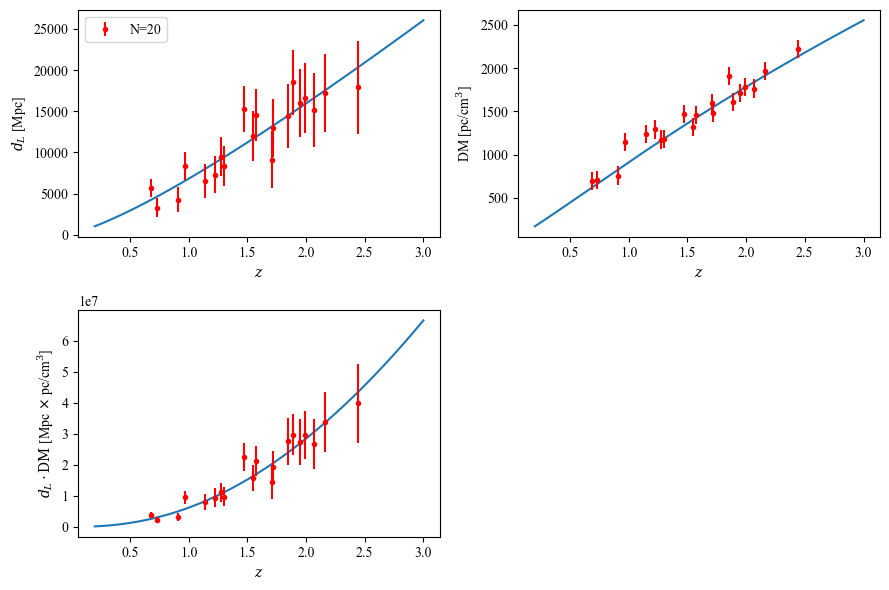

In [9]:
fig = plt.figure(figsize=(9,6))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)

ax1.plot(z_range, dL_values_fid)
ax1.errorbar(z_obs, dL_values_obs, yerr=s_dL_obs, marker='o', ls='', ms=3, c='r', label=f'N={len(z_obs)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(z_range, DM_values_fid)
ax2.errorbar(z_obs, DM_values_obs, yerr=SIGMA_DM, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

ax3.plot(z_range, dLDM_fid)
ax3.errorbar(z_obs, dLDM_obs, yerr=s_dLDM_obs, marker='o', ls='', ms=3, c='r')
ax3.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [Mpc $\times$ pc/cm$^3$]')
ax3.set_xlabel(r'$z$')

plt.tight_layout()
   
plt.show()

*Cosmological constraints*

In [10]:
### We create a grid of values for Om and Ho
Omega_m_array = np.linspace(0.0, 0.6, 100)
w_array = np.linspace(-3.0, 0.0, 140)

Om_, w_ = np.meshgrid(Omega_m_array, w_array)

In [11]:
### Fitting Om        
chi_fit = np.zeros_like(Omega_m_array)

for idx_Om, Om in enumerate(Omega_m_array):
    chi_square = 0
    for idx_z, z_val in enumerate(z_obs):
        dLDM = dLDM_measure(z_val, HUBBLE, Om, w=W_LAMBDA)        
            
        chi_square += (dLDM_obs[idx_z]-dLDM)**2/s_dLDM_obs[idx_z]**2  # For all events, add in χ^2
       
    chi_fit[idx_Om] = chi_square

In [12]:
### Finding the best-fit Om & error 
### See P. Gregory, p.260

## Find Om value
chi_1D_min = np.min(chi_fit)
id_Om_min = np.where(chi_fit==chi_1D_min)[0][0]

## Find sigma
sigma1_chi_fit = chi_1D_min+1
delta_chi = np.abs(chi_fit-sigma1_chi_fit)
delta_chi_min = np.min(delta_chi)
id_Om_sigma_1 = np.where(delta_chi==delta_chi_min)[0][0] # find id_Om when χ^2 differences==1

## Transform to the physical parameter of interest
Omega_fit = Omega_m_array[id_Om_min]
sigma_Om = np.abs(Omega_m_array[id_Om_min]-Omega_m_array[id_Om_sigma_1])

In [13]:
### Fitting Om & w
chi_fit_2D = np.zeros_like(Om_)

for idx_Om, Om in enumerate(tqdm(Omega_m_array)):
    for idx_w, w_val in enumerate(w_array):
        chi_square = 0
        for idx_z, z_val in enumerate(z_obs):
            dLDM = dLDM_measure(z_val, HUBBLE, Om, w=w_val)        
            
            chi_square += (dLDM_obs[idx_z]-dLDM)**2/s_dLDM_obs[idx_z]**2
    
        chi_fit_2D[idx_w, idx_Om] = chi_square

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:47<00:00,  2.10it/s]


For marginalisation of $\chi^2$, check [[Slides](http://astronomy.swin.edu.au/~cblake/StatsLecture3.pdf)] & [[YT video](https://youtu.be/TSNV-4K3Fws?t=1395)]. 

The probability of drawing a sample of data given a model is related to the $\chi^2$ value by the likelihood:

$$
\mathcal{L} (I|m) \sim e^{-\chi^2/2},
$$

i.e. minimising $\chi^2$ is equivalent of maximising the likelihood.

**NB:** $\chi^2$ assumes that the data values are normally distributed around the model (consistent with our mock data generation).

The process of marginalisation is the following:

1. From the $\chi^2$ values, we calculate the likelihood: $\mathcal{L} \sim e^{-\chi^2/2}$.
2. Normalise $\mathcal{L}$ to calculate probability in the grid (for 2 variables): $\Sigma_{a, b} \mathcal{L}_{2D}(a, b) = 1, \rightarrow P_{2D}(a, b)$.
3. Get the marginalised probability by summing over the parameter of non-interest: $P_{1D}(a) = \Sigma_b P_{2D}(a, b)$.

In [14]:
### Finding the best-fit Om & error [by marginalizing over w of the 2D model]

P2d = np.exp(-chi_fit_2D/2)  # Finding the pdf
P2d /= np.sum(P2d)  # Normalizing the pdf
P_Om = np.sum(P2d, axis=0)  # Marginalizing to get the parameter of interest

### Comparing (the same method) with numerical integration
### This doesn't change things - it's just a different normalization constant
P2d_int = np.exp(-chi_fit_2D/2)
P2d_norm = np.trapezoid(np.trapezoid(P2d_int, x=w_array, axis=0), x=Omega_m_array)

P2d_prob = P2d_int/P2d_norm

P1d_Om = np.trapezoid(P2d_prob, x=w_array, axis=0)
P1d_Om /= np.trapezoid(P1d_Om, x=Omega_m_array)

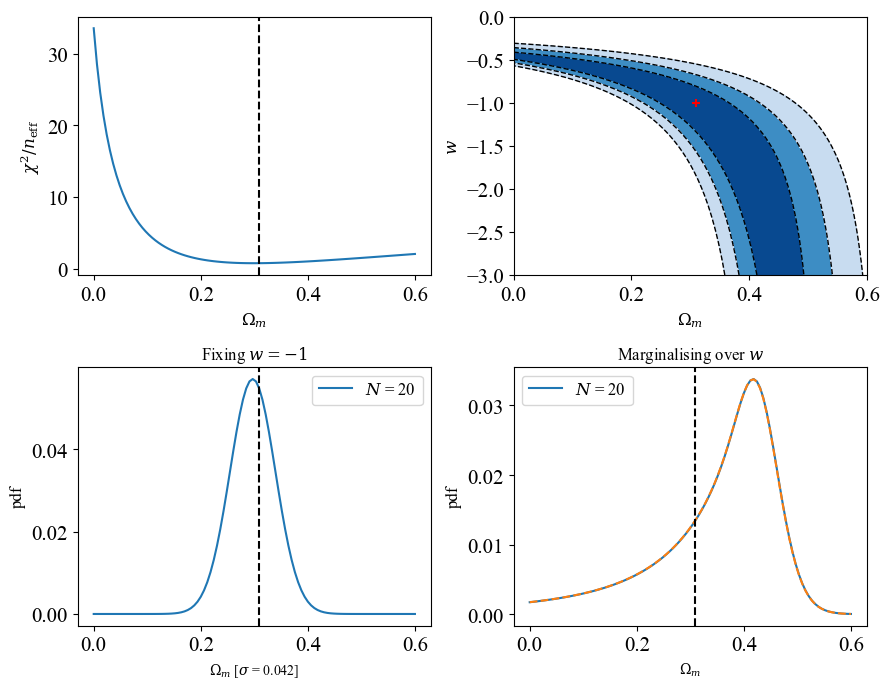

In [15]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)


ax1.plot(Omega_m_array, chi_fit/(len(z_obs)-1))
ax1.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax1.set_xlabel(r'$\Omega_m$', fontsize=12)
ax1.set_ylabel(r'$\chi^2/n_{\rm eff}$', fontsize=12) # chi^2/(n-1) for real data
ax1.tick_params(axis='both', which='major', labelsize=15)

chi_2D_min = np.min(chi_fit_2D)
ax2.contourf(Om_, w_, chi_fit_2D, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax2.contour(Om_, w_, chi_fit_2D, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
            colors='black', linestyles='--', linewidths=1)
ax2.scatter(OMEGA_MATTER, W_LAMBDA, marker='+', c='r', zorder=10)
ax2.set_xlabel(r'$\Omega_m$', fontsize=12)
ax2.set_ylabel(r'$w$', fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=15)

ax3.plot(Omega_m_array, normalise(gaussian_pdf(Omega_m_array, Omega_fit, sigma_Om)),\
         label=fr'$N$ = {len(z_obs)}')
ax3.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax3.set_xlabel(fr'$\Omega_m$ [$\sigma$ = {round(sigma_Om, 3)}]')
ax3.set_ylabel('pdf', fontsize=12)
ax3.legend(fontsize=12)
ax3.set_title(r'Fixing $w=-1$', fontsize=12)
ax3.tick_params(axis='both', which='major', labelsize=15)

ax4.plot(Omega_m_array, normalise(P_Om),\
         label=fr'$N$ = {len(z_obs)}')
ax4.plot(Omega_m_array, normalise(P1d_Om), ls='--')
ax4.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax4.set_xlabel(fr'$\Omega_m$')
ax4.set_ylabel('pdf', fontsize=12)
ax4.legend(fontsize=12)
ax4.set_title(r'Marginalising over $w$', fontsize=12)
ax4.tick_params(axis='both', which='major', labelsize=15)

if SAVING_FIGS:
    plt.savefig("figures/DeltaE_PhiDM_LCDM.pdf", dpi=200, bbox_inches='tight')

plt.tight_layout()
plt.show()

**NB**: Compare with Figures 3 & 4 of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]. Variations are possible and are the result of the data generation process.

-----------------------------------------

**Comparing 3 different redshift distributions of sources**

For details, see `Realistic_sources` notebook.

In [16]:
N_events_Wei = 50

In [17]:
z_obs, dL_values_obs, s_dL_obs, DM_values_obs, SIGMA_DM, chi_fit_2D, Om_, w_, Omega_m_array, Omega_fit, sigma_Om, P_Om =\
wei_2d_analysis(N_events=N_events_Wei, z_max=3.0)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:53<00:00,  1.14s/it]


In [18]:
z_obs_uni, dL_values_obs_uni, s_dL_obs_uni,\
DM_values_obs_uni, SIGMA_DM_uni, chi_fit_2D_uni, Om_uni, w_uni, Omega_m_array_uni,\
Omega_fit_uni, sigma_Om_uni, P_Om_uni =\
wei_2d_analysis(N_events=N_events_Wei, z_method='uniform', z_max=3.0)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:14<00:00,  1.35s/it]


In [19]:
z_obs_ln, dL_values_obs_ln, s_dL_obs_ln,\
DM_values_obs_ln, SIGMA_DM_ln, chi_fit_2D_ln, Om_ln, w_ln, Omega_m_array_ln,\
Omega_fit_ln, sigma_Om_ln, P_Om_ln =\
wei_2d_analysis(N_events=N_events_Wei, z_method='lognormal', z_max=3.0)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:47<00:00,  1.07s/it]


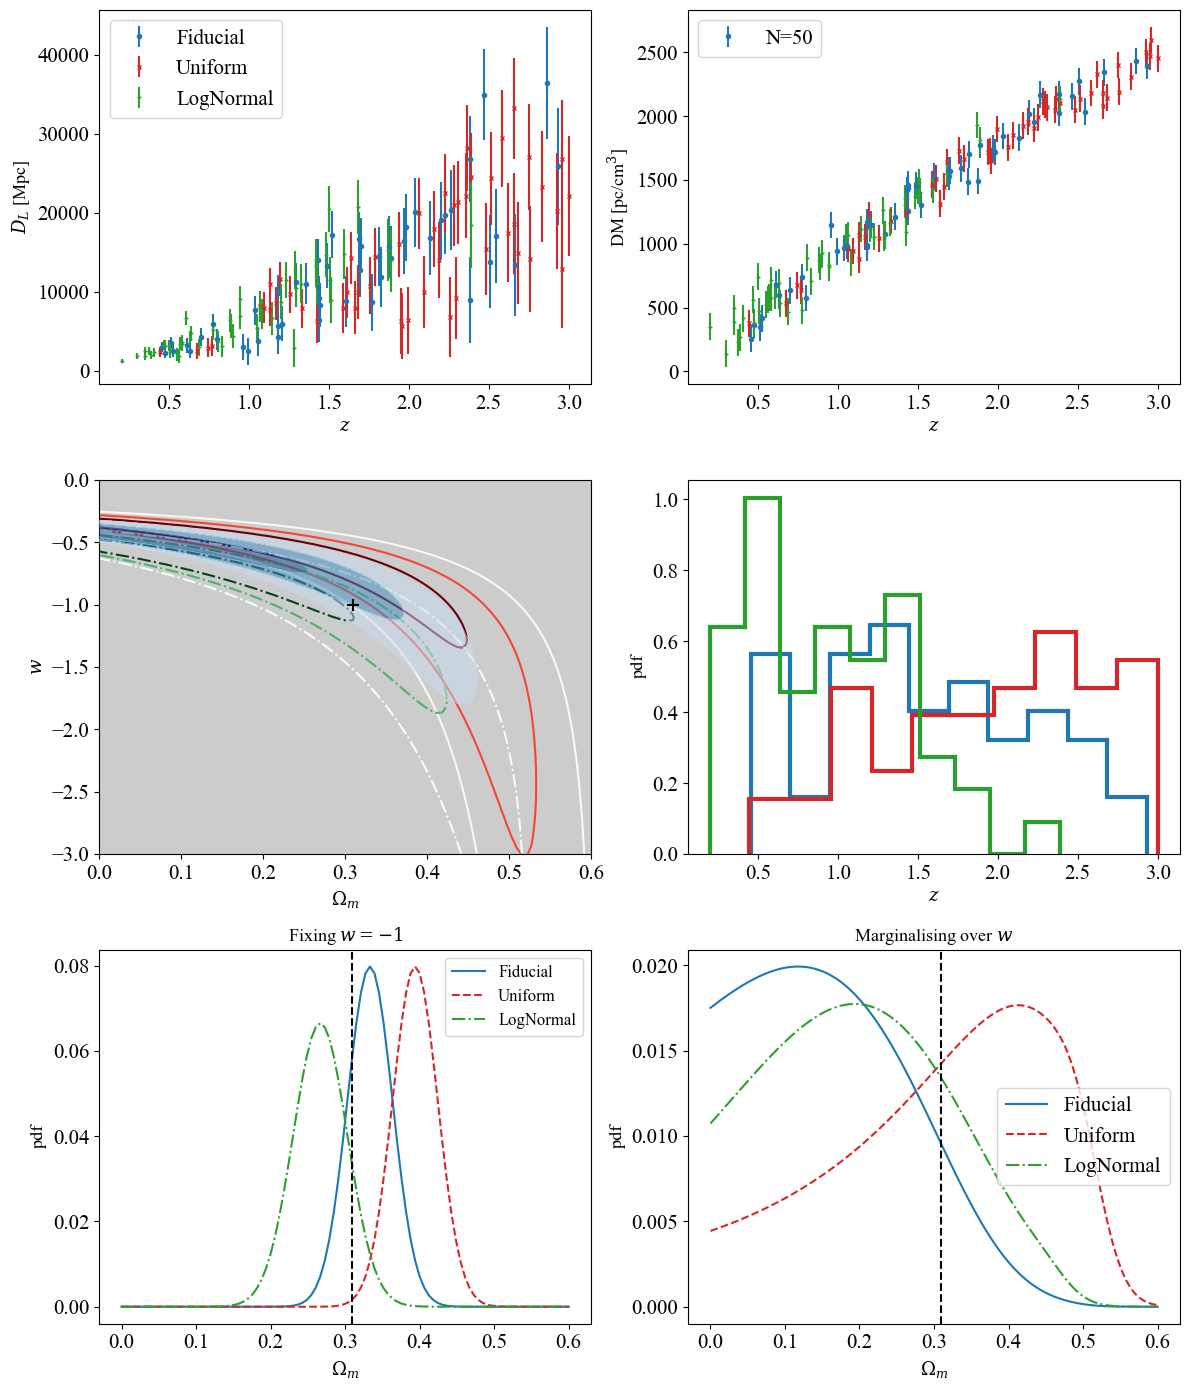

In [20]:
fig = plt.figure(figsize=(12, 14))
ax1 = fig.add_subplot(321)
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
ax5 = fig.add_subplot(325)
ax6 = fig.add_subplot(326)

ax1.errorbar(z_obs, dL_values_obs, yerr=s_dL_obs, marker='o', ls='', ms=3, c='tab:blue', label='Fiducial')
ax1.errorbar(z_obs_uni, dL_values_obs_uni, yerr=s_dL_obs_uni, marker='x', ls='', ms=3, c='tab:red', label='Uniform')
ax1.errorbar(z_obs_ln, dL_values_obs_ln, yerr=s_dL_obs_ln, marker='+', ls='', ms=3, c='tab:green', label='LogNormal')
ax1.set_ylabel(r'$D_{L}$ [Mpc]', fontsize=13)
ax1.set_xlabel(r'$z$', fontsize=13)
ax1.legend(loc='upper left', fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=15)

ax2.errorbar(z_obs, DM_values_obs, yerr=SIGMA_DM, marker='o', ls='', ms=3, c='tab:blue', label=f'N={N_events_Wei}')
ax2.errorbar(z_obs_uni, DM_values_obs_uni, yerr=SIGMA_DM_uni, marker='x', ls='', ms=3, c='tab:red')
ax2.errorbar(z_obs_ln, DM_values_obs_ln, yerr=SIGMA_DM_ln, marker='+', ls='', ms=3, c='tab:green')
ax2.set_ylabel(r'DM [pc/cm$^3$]', fontsize=13)
ax2.set_xlabel(r'$z$', fontsize=13)
ax2.legend(loc='upper left', fontsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)

chi_2D_min = np.min(chi_fit_2D)
ax3.contourf(Om_, w_, chi_fit_2D, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
            cmap='Blues_r', alpha=0.5, zorder=5)

chi_2D_min_uni = np.min(chi_fit_2D_uni)
# ax3.contourf(Om_uni, w_uni, chi_fit_2D_uni, levels=[chi_2D_min_uni, chi_2D_min_uni+2.3, chi_2D_min_uni+6.17, chi_2D_min_uni+11.8],\
#             linestyles='dashed', cmap='Reds_r', alpha=0.7)
ax3.contour(Om_uni, w_uni, chi_fit_2D_uni, levels=[chi_2D_min_uni+2.3, chi_2D_min_uni+6.17, chi_2D_min_uni+11.8],\
            linestyles='-', cmap='Reds_r')

chi_2D_min_ln = np.min(chi_fit_2D_ln)
# ax3.contourf(Om_ln, w_ln, chi_fit_2D_ln, levels=[chi_2D_min_ln, chi_2D_min_ln+2.3, chi_2D_min_ln+6.17, chi_2D_min_ln+11.8],\
#             linestyles='dotted', cmap='Greens_r', alpha=0.7)
ax3.contour(Om_ln, w_ln, chi_fit_2D_ln, levels=[chi_2D_min_ln+2.3, chi_2D_min_ln+6.17, chi_2D_min_ln+11.8],\
            linestyles='-.', cmap='Greens_r')

ax3.scatter(OMEGA_MATTER, W_LAMBDA, marker='+', c='black', s=80, zorder=10)
ax3.set_xlabel(r'$\Omega_m$', fontsize=13)
ax3.set_ylabel(r'$w$', fontsize=13)
ax3.tick_params(axis='both', which='major', labelsize=15)
ax3.set_facecolor('0.8')

ax4.hist(z_obs, density=True, histtype='step', color='tab:blue', linewidth=3)
ax4.hist(z_obs_uni, density=True, histtype='step', color='tab:red', linewidth=3)
ax4.hist(z_obs_ln, density=True, histtype='step', color='tab:green', linewidth=3)
ax4.set_xlabel(r'$z$', fontsize=13)
ax4.set_ylabel('pdf', fontsize=13)
ax4.tick_params(axis='both', which='major', labelsize=15)


ax5.plot(Omega_m_array, normalise(gaussian_pdf(Omega_m_array, Omega_fit, sigma_Om)),\
         label='Fiducial', c='tab:blue')
ax5.plot(Omega_m_array_uni, normalise(gaussian_pdf(Omega_m_array_uni, Omega_fit_uni, sigma_Om_uni)), ls='--',\
         label='Uniform', c='tab:red')
ax5.plot(Omega_m_array_ln, normalise(gaussian_pdf(Omega_m_array_ln, Omega_fit_ln, sigma_Om_ln)), ls='-.',\
         label='LogNormal', c='tab:green')
ax5.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax5.set_xlabel(r'$\Omega_m$', fontsize=13)
ax5.set_ylabel('pdf', fontsize=13)
ax5.legend(fontsize=12)
ax5.set_title(r'Fixing $w=-1$', fontsize=13)
ax5.tick_params(axis='both', which='major', labelsize=15)

ax6.plot(Omega_m_array, normalise(P_Om),\
         label='Fiducial', c='tab:blue')
ax6.plot(Omega_m_array_uni, normalise(P_Om_uni), ls='--',\
         label='Uniform', c='tab:red')
ax6.plot(Omega_m_array_ln, normalise(P_Om_ln), ls='-.',\
         label='LogNormal', c='tab:green')
ax6.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax6.set_xlabel(r'$\Omega_m$', fontsize=13)
ax6.set_ylabel('pdf', fontsize=13)
ax6.legend(fontsize=15)
ax6.set_title('Marginalising over $w$', fontsize=13)
ax6.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

------------------------------------------

## 2. Cosmological inference without redshift information (proof of concept) <a name="Precise_distance_info"></a>

The method above assumes determination of the redshift of the GWs/FRB source. This limits the analyses to very well localised events. We develop below a method to infer cosmological parameters without any redshift knowledge.

#### 2.1. Ideal luminosity distances

When we do not have redshift information, we can use $d_L$ (luminosity distance) from GWs and ${\rm DM}_{\rm IGM}$ from the FRBs to put constraints on the cosmological parameters ($H_0, \Omega_m, w$).

In this simplified case, we assume idealised $d_L$, i.e. precise determination of distances (from the GWs). Then, we can calculate:

$$
d_L^{\rm obs}\quad \underrightarrow{(H_0, \Omega_m, w)}\quad z \quad \underrightarrow{(H_0, \Omega_m, w)}\quad {\rm DM},
$$

which can then be compared to ${\rm DM}^{\rm obs}$, with the standard $\chi^2$ statistic


$$
\chi^2 (H_0, \Omega_m, w) = \frac{[{\rm DM}^{\rm obs}-{\rm DM}(H_0, \Omega_m, w)]^2}{\sigma_{{\rm DM}}^2},
$$

where for $\sigma_{{\rm DM}}$ we assume a value of $\sigma_{{\rm DM}} \sim 105$ pc/cm$^3$ (as above).

Return to TOC [here](#toc).

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. 

The mock obsersations are based on these, but with scatter that follows a guassian distribution, e.g. $DM^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

For the observed luminosity distances, we **then assume zero errors**, i.e. $\sigma_{d_L} \rightarrow 0$. This means that for each $d_L$ we implicitly have a specific ${\rm DM}$. From the fiducial ${\rm DM}$, we calculate the scatter as above, so that observed dispersion measures will follow a more realistic distribution, i.e. not fall exactly on the fiducial cosmology expectation.

We then use the luminosity distances to infer redshifts as an intermediate step and then dispersion measures, as detailed above.

With these we calculate the $\chi^2$ statistic and constrain cosmology.

In [21]:
### Create a redshift range
z_range = np.linspace(0.2, 3.0, 500)

### Sample the obervations
z_obs = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=20, method='rates')

dL_values_fid = np.zeros_like(z_range)
DM_values_fid = np.zeros_like(z_range)

dL_values_obs = np.zeros_like(z_obs)
DM_values_obs = np.zeros_like(z_obs)
s_dL_obs = np.zeros_like(z_obs)


### Create mock observations (following the fiducial cosmology + scatter)
for idx, z_val in enumerate(z_obs): 
    dL_fid = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_fid = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    
    s_DM_fid = SIGMA_DM
    
    dL_values_obs[idx] = rng.normal(dL_fid, 0.01*dL_fid)
    DM_values_obs[idx] = rng.normal(DM_fid, s_DM_fid)
    
### Create the fiducial cosmo values (with zero scatter) for comparison    
for idx, z_val in enumerate(z_range): 
    dL_values_fid[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_values_fid[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)   

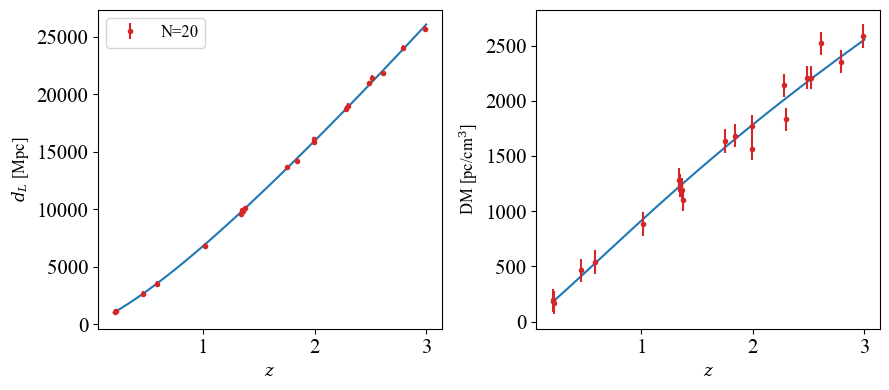

In [22]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_range, dL_values_fid)
ax1.errorbar(z_obs, dL_values_obs, yerr=0.01*dL_fid, marker='o', ls='', ms=3, c='tab:red', label=f'N={len(z_obs)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]', fontsize=12)
ax1.set_xlabel(r'$z$', fontsize=12)
ax1.legend(loc='upper left', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=15)

ax2.plot(z_range, DM_values_fid)
ax2.errorbar(z_obs, DM_values_obs, yerr=SIGMA_DM, marker='o', ls='', ms=3, c='tab:red')
ax2.set_ylabel(r'DM [pc/cm$^3$]', fontsize=12)
ax2.set_xlabel(r'$z$', fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()

if SAVING_FIGS:
    plt.savefig(save_location+"dL_DM_with_z.pdf", bbox_inches='tight', dpi=300)

plt.show()

**NB**: $d_L$ does not play a role in the constraints here. Only the ${\rm DM}^{\rm obs}$ values.

*Cosmological constraints*

We infer:

- $H_0$ with $\Omega_m, w$ fixed to their fiducial values
- $H_0, \Omega_m$ with $w$ fixed to its fiducial value
- $H_0, \Omega_m, w$

In [23]:
H0_array = np.linspace(10, 140, 100)
Omega_m_array = np.linspace(0.1, 0.5, 40)
w_array = np.linspace(-3.0, 0.0, 45)

H_Om, Om_H0 = np.meshgrid(H0_array, Omega_m_array)
H_w, w_H = np.meshgrid(H0_array, w_array)
Om_w, w_Om = np.meshgrid(Omega_m_array, w_array)

H3D_, Om3D_, w3D_ = np.meshgrid(H0_array, Omega_m_array, w_array)

- **1 & 2 parameter fit**

In [24]:
### Fitting only H0
chi_fit = np.zeros_like(H0_array)

for idx_h, H0 in enumerate(H0_array):
    chi_square = 0
    for idx_z, z_val in enumerate(z_obs):
        DM = dispersion_measure(z_val, H0, OMEGA_MATTER, w=W_LAMBDA)
        
        chi_square += (DM_values_obs[idx_z]-DM)**2/SIGMA_DM**2  # For all events, add in χ^2
    
    chi_fit[idx_h] = chi_square    

In [25]:
## Find H0 value
chi_1D_min = np.min(chi_fit)
id_H0_min = np.where(chi_fit==chi_1D_min)[0][0]

## Find sigma
sigma1_chi_fit = chi_1D_min+1
delta_chi = np.abs(chi_fit-sigma1_chi_fit)
delta_chi_min = np.min(delta_chi)
id_H0_sigma_1 = np.where(delta_chi==delta_chi_min)[0][0]

## Transform to the physical parameter of interest
H0_fit = H0_array[id_H0_min]
sigma_H0 = np.abs(H0_array[id_H0_min]-H0_array[id_H0_sigma_1])

if sigma_H0==0:
    print("Higher resolution is needed in the H0 grid")

In [26]:
### Fitting H0 & Om
chi_fit_2D = np.zeros_like(H_Om)

for idx_h, H0 in enumerate(tqdm(H0_array)):
    for idx_Om, Om in enumerate(Omega_m_array):
        chi_square = 0
        for idx_z, z_val in enumerate(z_obs):
            DM = dispersion_measure(z_val, H0, Om, w=W_LAMBDA)
        
            chi_square += (DM_values_obs[idx_z]-DM)**2/SIGMA_DM**2
    
        chi_fit_2D[idx_Om, idx_h] = chi_square

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 15.72it/s]


In [27]:
### Finding the best-fit H0 & error [by marginalising over Om of the 2D model]

P2d = normalise(np.exp(-chi_fit_2D/2))
P_H0 = np.sum(P2d, axis=0)

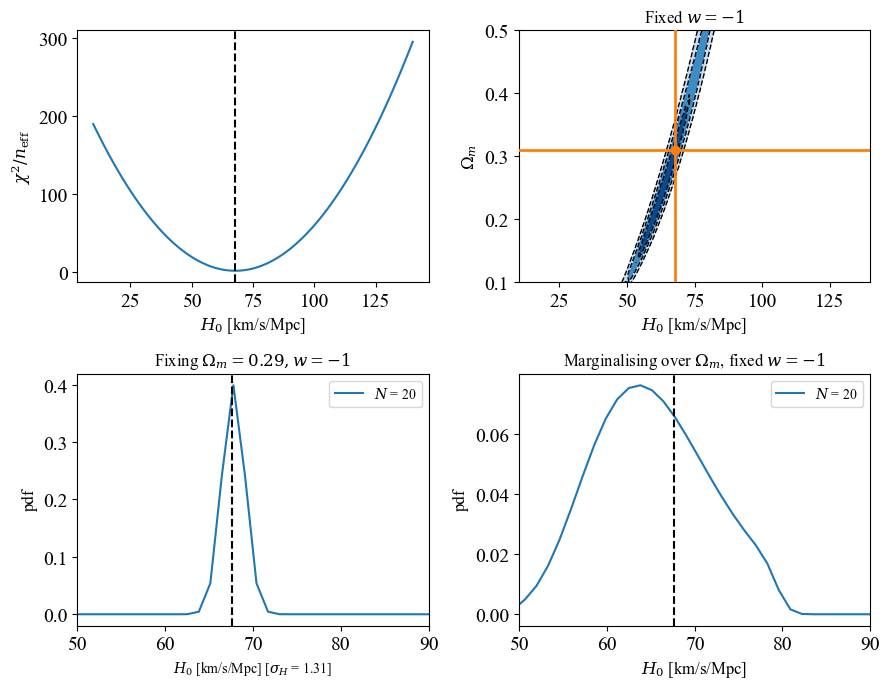

In [28]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)


ax1.plot(H0_array, chi_fit/(len(z_obs)-1))
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax1.set_ylabel(r'$\chi^2/n_{\rm eff}$', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=14)

chi_2D_min = np.min(chi_fit_2D)
ax2.contourf(H_Om, Om_H0, chi_fit_2D, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax2.contour(H_Om, Om_H0, chi_fit_2D, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
            colors='black', linestyles='--', linewidths=1)
ax2.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', zorder=10)
ax2.axhline(y=OMEGA_MATTER, lw=2, c='tab:orange', zorder=10)
ax2.axvline(x=HUBBLE, lw=2, c='tab:orange', zorder=10)
ax2.set_ylabel(r'$\Omega_m$', fontsize=12)
ax2.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax2.set_title(r'Fixed $w=-1$', fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=14)

ax3.plot(H0_array, normalise(gaussian_pdf(H0_array, H0_fit, sigma_H0)),\
         label=fr'$N$ = {len(z_obs)}')
ax3.axvline(x=HUBBLE, ls='--', c='black')
ax3.set_xlabel(fr'$H_0$ [km/s/Mpc] [$\sigma_H$ = {round(sigma_H0, 2)}]')
ax3.set_ylabel('pdf', fontsize=12)
ax3.set_xlim(50, 90)
ax3.legend()
ax3.set_title(r'Fixing $\Omega_m = 0.29, w=-1$', fontsize=12)
ax3.tick_params(axis='both', which='major', labelsize=14)

ax4.plot(H0_array, normalise(P_H0),\
         label=fr'$N$ = {len(z_obs)}')
ax4.axvline(x=HUBBLE, ls='--', c='black')
ax4.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax4.set_ylabel('pdf', fontsize=12)
ax4.legend()
ax4.set_xlim(50, 90)
ax4.set_title(r'Marginalising over $\Omega_m$, fixed $w=-1$', fontsize=12)
ax4.tick_params(axis='both', which='major', labelsize=14)

if SAVING_FIGS:
    plt.savefig(save_location+"idealised_2D_inference.pdf", bbox_inches='tight', dpi=300)


plt.tight_layout()
plt.show()

---------------------------

In [29]:
N_events_2D = 50

In [30]:
z_obs, _, chi_fit_2D, H_Om, Om_H0, H0_array, P_H0 =\
ideal_distances_analysis(N_events=N_events_2D, Ho_res=95, Om_res=60, z_max=3.0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [00:19<00:00,  4.87it/s]


In [31]:
z_obs_uni, _, chi_fit_2D_uni, _, _, _, P_H0_uni =\
ideal_distances_analysis(N_events=N_events_2D, Ho_res=95, Om_res=60, z_method='uniform', z_max=3.0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [00:19<00:00,  4.77it/s]


In [32]:
z_obs_ln, _, chi_fit_2D_ln, _, _, _, P_H0_ln =\
ideal_distances_analysis(N_events=N_events_2D, Ho_res=95, Om_res=60, z_method='lognormal', z_max=3.0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [00:19<00:00,  4.87it/s]


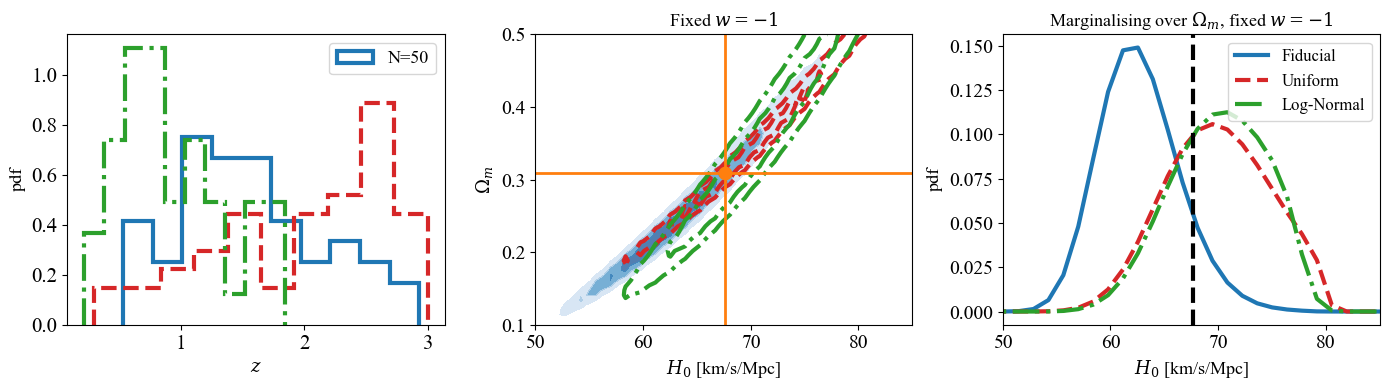

In [33]:
fig = plt.figure(figsize=(14, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)


ax1.hist(z_obs, density=True, histtype='step', color='tab:blue', linewidth=3, label=f'N={N_events_2D}')
ax1.hist(z_obs_uni, density=True, histtype='step', color='tab:red', linewidth=3, linestyle='--')
ax1.hist(z_obs_ln, density=True, histtype='step', color='tab:green', linewidth=3, linestyle='-.')
ax1.set_xlabel(r'$z$', fontsize=13)
ax1.set_ylabel('pdf', fontsize=13)
ax1.legend(loc='upper right', fontsize=13)
ax1.tick_params(axis='both', which='major', labelsize=15)


chi_2D_min = np.min(chi_fit_2D)
# ax3.contour(H_Om, Om_H0, chi_fit_2D, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax2.contourf(H_Om, Om_H0, chi_fit_2D, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
             cmap='Blues_r', alpha=0.7)

chi_2D_min_uni = np.min(chi_fit_2D_uni)
ax2.contour(H_Om, Om_H0, chi_fit_2D_uni, levels=[chi_2D_min_uni+2.3, chi_2D_min_uni+6.17],\
            linestyles='--', colors='tab:red', linewidths=3)
# ax3.contourf(H_Om, Om_H0, chi_fit_2D_uni, levels=[chi_2D_min_uni, chi_2D_min_uni+2.3, chi_2D_min_uni+6.17, chi_2D_min_uni+11.8],\
#             linestyles='dashed', cmap='Reds_r', alpha=0.7)

chi_2D_min_ln = np.min(chi_fit_2D_ln)
ax2.contour(H_Om, Om_H0, chi_fit_2D_ln, levels=[chi_2D_min_ln+2.3, chi_2D_min_ln+6.17],\
            linestyles='-.', colors='tab:green', linewidths=3)
# ax3.contourf(H_Om, Om_H0, chi_fit_2D_ln, levels=[chi_2D_min_ln, chi_2D_min_ln+2.3, chi_2D_min_ln+6.17, chi_2D_min_ln+11.8],\
#             linestyles='dotted', cmap='Greens_r', zorder=-1)

ax2.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', s=80, zorder=10)
ax2.axhline(y=OMEGA_MATTER, c='tab:orange', lw=2)
ax2.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax2.set_ylabel(r'$\Omega_m$', fontsize=13)
ax2.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=13)
ax2.set_title(r'Fixed $w=-1$', fontsize=13)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xlim(50, 85)


ax3.plot(H0_array, normalise(P_H0),\
         label='Fiducial', c='tab:blue', lw=3)
ax3.plot(H0_array, normalise(P_H0_uni), ls='--',\
         label='Uniform', c='tab:red', lw=3)
ax3.plot(H0_array, normalise(P_H0_ln), ls='-.',\
         label='Log-Normal', c='tab:green', lw=3)
ax3.axvline(x=HUBBLE, ls='--', c='black', lw=3)
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=13)
ax3.set_ylabel('pdf', fontsize=13)
ax3.legend(fontsize=12)
ax3.set_title(r'Marginalising over $\Omega_m$, fixed $w=-1$', fontsize=13)
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.set_xlim(50, 85)

plt.tight_layout()

if SAVING_FIGS:
    plt.savefig(save_location+"idealised_2D_inference_populations.pdf", bbox_inches='tight', dpi=400)

plt.show()

-------------------------------------------

**3 parameter fit** (this takes more time, if the grid is high-resolution)

In [34]:
### Create a redshift range
z_range = np.linspace(0.2, 3.0, 500)

### Sample the obervations
z_obs = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=50, method='powerlaw')

DM_values_obs = np.zeros_like(z_obs)

### Create mock observations (following the fiducial cosmology + scatter)
for idx, z_val in enumerate(z_obs): 
    DM_fid = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    s_DM_fid = SIGMA_DM
    
    DM_values_obs[idx] = rng.normal(DM_fid, s_DM_fid)

In [35]:
H0_array = np.linspace(10, 140, 70)
Omega_m_array = np.linspace(0.1, 0.5, 40)
w_array = np.linspace(-3.0, 0.0, 45)

H_Om, Om_H0 = np.meshgrid(H0_array, Omega_m_array)
H_w, w_H = np.meshgrid(H0_array, w_array)
Om_w, w_Om = np.meshgrid(Omega_m_array, w_array)

H3D_, Om3D_, w3D_ = np.meshgrid(H0_array, Omega_m_array, w_array)

In [36]:
### Fitting H0 & Om & w
chi_fit_3D = np.zeros_like(H3D_)

for idx_h, H0 in enumerate(tqdm(H0_array)):
    for idx_Om, Om in enumerate(Omega_m_array):
        for idx_w, W in enumerate(w_array):
            chi_square = 0
            for idx_z, z_val in enumerate(z_obs):
                DM = dispersion_measure(z_val, H0, Om, w=W)
        
                chi_square += (DM_values_obs[idx_z]-DM)**2/SIGMA_DM**2
    
            chi_fit_3D[idx_Om, idx_h, idx_w] = chi_square

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [08:34<00:00,  7.35s/it]


- 2D constraints, with one parameter fixed

In [37]:
### In this part, we fix one of the three cosmological variables to their default value, 
### and plot the remaining 2D constraints (of the other two variables).

index_W_LAMBDA = np.where(np.abs(w_array-W_LAMBDA)==np.min(np.abs(w_array-W_LAMBDA)))[0][0]
chi_2D_H0Om = chi_fit_3D[:, :, index_W_LAMBDA]

index_OMEGA_MATTER = np.where(np.abs(Omega_m_array-OMEGA_MATTER)==np.min(np.abs(Omega_m_array-OMEGA_MATTER)))[0][0]
chi_2D_H0w = chi_fit_3D[index_OMEGA_MATTER, :, :]

index_HUBBLE = np.where(np.abs(H0_array-HUBBLE)==np.min(np.abs(H0_array-HUBBLE)))[0][0]
chi_2D_Omw = chi_fit_3D[:, index_HUBBLE, :]

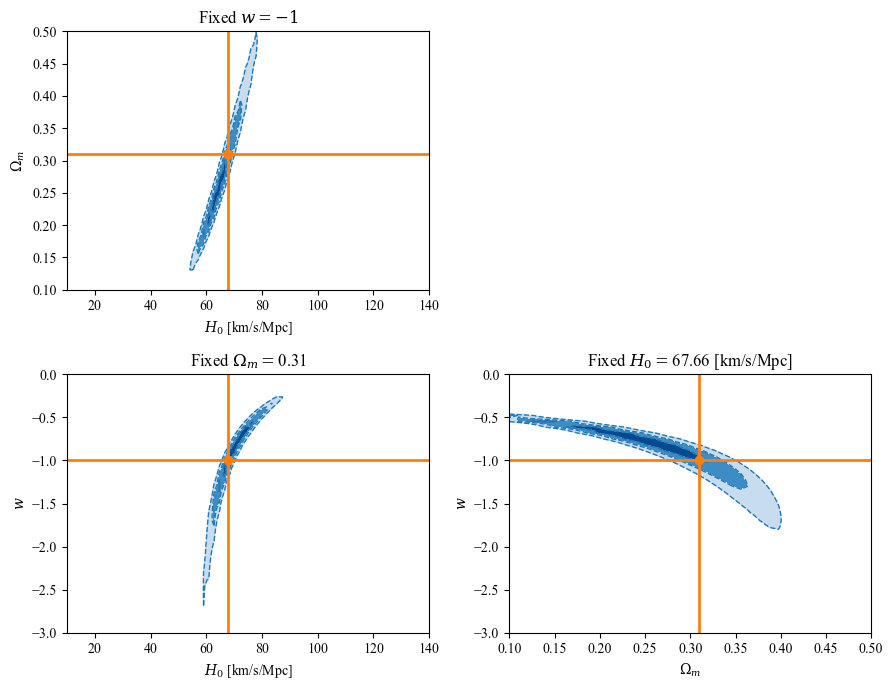

In [38]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)


chi_2D_min = np.min(chi_2D_H0Om)
ax1.contourf(H_Om, Om_H0, chi_2D_H0Om, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax1.contour(H_Om, Om_H0, chi_2D_H0Om, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
           colors='tab:blue', linestyles='--', linewidths=1)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', zorder=10)
ax1.axhline(y=OMEGA_MATTER, c='tab:orange', lw=2)
ax1.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
# ax1.set_facecolor('0.9')
ax1.set_title(r'Fixed $w=-1$')

chi_2D_min = np.min(chi_2D_H0w)
ax3.contourf(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax3.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
            colors='tab:blue', linestyles='--', linewidths=1)
ax3.scatter(HUBBLE, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax3.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax3.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax3.set_ylabel(r'$w$')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
# ax3.set_facecolor('0.9')
ax3.set_title(r'Fixed $\Omega_m=$'+f'{round(OMEGA_MATTER, 2)}')

chi_2D_min = np.min(chi_2D_Omw)
ax4.contourf(Om_w, w_Om, chi_2D_Omw.T, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax4.contour(Om_w, w_Om, chi_2D_Omw.T, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
            colors='tab:blue', linestyles='--', linewidths=1)
ax4.scatter(OMEGA_MATTER, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax4.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax4.axvline(x=OMEGA_MATTER, c='tab:orange', lw=2)
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_ylabel(r'$w$')
# ax4.set_facecolor('0.9')
ax4.set_title(r'Fixed $H_0=$'+f'{HUBBLE} [km/s/Mpc]')

if SAVING_FIGS:
    plt.savefig(save_location+"idealised_3D_inference.pdf", bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

- 2D constraints, marginalising over the remaining parameter

In [39]:
### Finding the best-fit H0 & Om & w [by marginalising over parameters of the 3D model]

## The detailed integration is not needed. It introduces some extra constant terms
## that are absorbed in the normalisation procedure in any case.

P3d = np.exp(-chi_fit_3D/2)
P3d_norm = np.sum(P3d) #np.trapz(np.trapz(np.trapz(P3d, x=w_array, axis=2), x=Omega_m_array, axis=0), x=H0_array)

P3d /= P3d_norm

# P2d_H0Om = np.trapz(P3d, x=w_array, axis=2)
# P2d_H0w = np.trapz(P3d, x=Omega_m_array, axis=0)
# P2d_Omw = np.trapz(P3d, x=H0_array, axis=1)

P2d_H0Om = np.sum(P3d, axis=2)
P2d_H0w = np.sum(P3d, axis=0)
P2d_Omw = np.sum(P3d, axis=1)

**NB - Percentages in contour plots**: 

Above we have calculated the 2D probabilities at each point of the grid. We want to find the contours that signify a specific cumulative probability. We follow the suggestion [here](https://stackoverflow.com/questions/37890550/python-plotting-percentile-contour-lines-of-a-probability-distribution).

The method creates some thresholds that depend on the grid probabilities, and sums up all points that are above these to calculate cummulative probabilities.

In [40]:
n = 1000

## Marginalise w
t_H0Om = np.linspace(0, P2d_H0Om.max(), n)
integral_H0Om = ((P2d_H0Om >= t_H0Om[:, None, None]) * P2d_H0Om).sum(axis=(1,2))
f_H0Om = interpolate.interp1d(integral_H0Om, t_H0Om)
t_contours_H0Om = f_H0Om(np.array([0.99, 0.95, 0.68]))

## Marginalise Om
t_H0w = np.linspace(0, P2d_H0w.max(), n)
integral_H0w = ((P2d_H0w >= t_H0w[:, None, None]) * P2d_H0w).sum(axis=(1,2))
f_H0w = interpolate.interp1d(integral_H0w, t_H0w)
t_contours_H0w = f_H0w(np.array([0.99, 0.95, 0.68]))

## Marginalise H0
t_Omw = np.linspace(0, P2d_Omw.max(), n)
integral_Omw = ((P2d_Omw >= t_Omw[:, None, None]) * P2d_Omw).sum(axis=(1,2))
f_Omw = interpolate.interp1d(integral_Omw, t_Omw)
t_contours_Omw = f_Omw(np.array([0.99, 0.95, 0.68]))

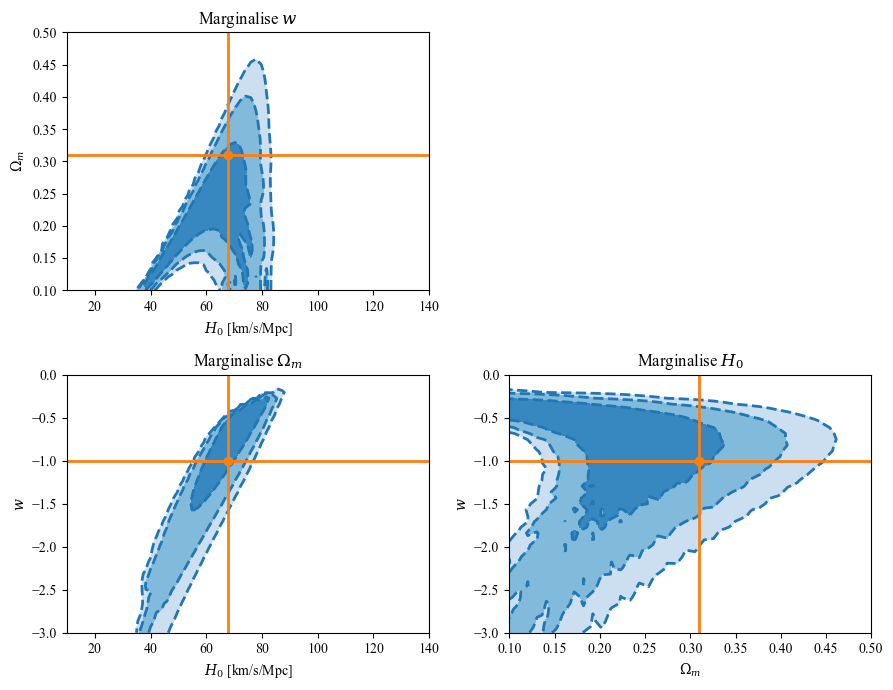

In [41]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = plt.get_cmap("Blues", 10)


ax1.contourf(H_Om, Om_H0, P2d_H0Om, levels=t_contours_H0Om, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, P2d_H0Om, levels=t_contours_H0Om, colors="tab:blue", linewidths=2, linestyles='--')
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', zorder=10)
ax1.axhline(y=OMEGA_MATTER, c='tab:orange', lw=2)
ax1.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_facecolor('1.0')
ax1.set_title(r'Marginalise $w$')


ax3.contourf(H_w, w_H, P2d_H0w.T, levels=t_contours_H0w, colors=[blues(2), blues(4), blues(6)], extend='max')
ax3.contour(H_w, w_H, P2d_H0w.T, levels=t_contours_H0w, colors="tab:blue", linewidths=2, linestyles='--')
ax3.scatter(HUBBLE, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax3.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax3.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax3.set_ylabel(r'$w$')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax3.set_facecolor('1.0')
ax3.set_title(r'Marginalise $\Omega_m$')


ax4.contourf(Om_w, w_Om, P2d_Omw.T, levels=t_contours_Omw, colors=[blues(2), blues(4), blues(6)], extend='max')
ax4.contour(Om_w, w_Om, P2d_Omw.T, levels=t_contours_Omw, colors="tab:blue", linewidths=2, linestyles='--')
ax4.scatter(OMEGA_MATTER, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax4.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax4.axvline(x=OMEGA_MATTER, c='tab:orange', lw=2)
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_ylabel(r'$w$')
ax4.set_facecolor('1.0')
ax4.set_title(r'Marginalise $H_0$')

plt.tight_layout()

if SAVING_FIGS:
    plt.savefig(save_location+"idealised_3D_inference_marginalised.pdf", bbox_inches='tight', dpi=300)

plt.show()

---------------------------------------------------

In [42]:
z_obs, DM_values_obs, H_Om, Om_H0, H_w, w_H, Om_w, w_Om, chi_2D_H0Om, chi_2D_H0w, chi_2D_Omw,\
P2d_H0Om, P2d_H0w, P2d_Omw, t_contours_H0Om, t_contours_H0w, t_contours_Omw =\
ideal_distances_analysis(N_events=50, Ho_res=70, Om_res=55, w_res=55, fit='3D', z_max=3.0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [15:08<00:00, 12.98s/it]


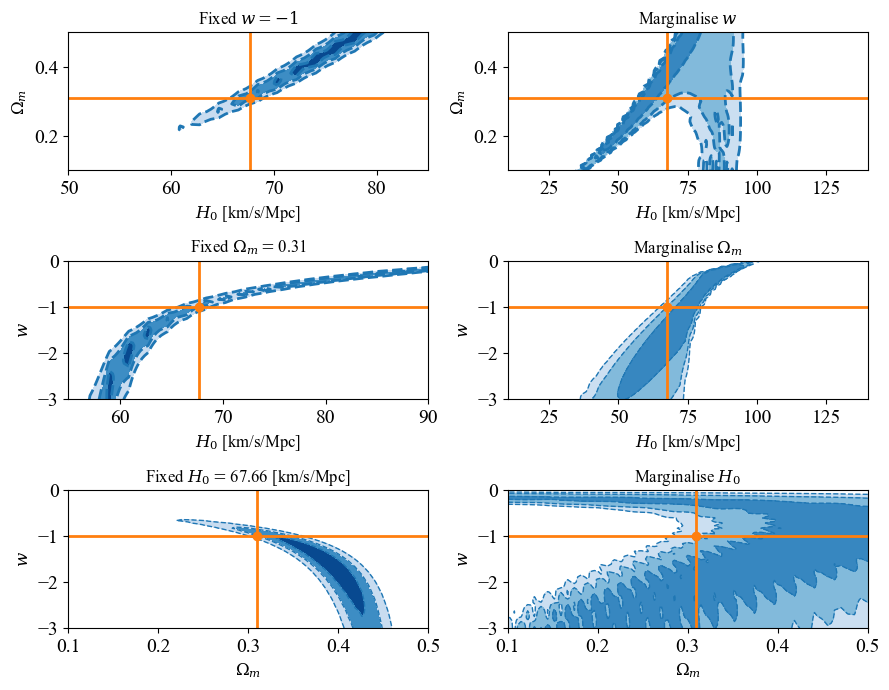

In [43]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(321)
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
ax5 = fig.add_subplot(325)
ax6 = fig.add_subplot(326)


blues = plt.get_cmap("Blues", 10)


chi_2D_min = np.min(chi_2D_H0Om)
ax1.contourf(H_Om, Om_H0, chi_2D_H0Om, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax1.contour(H_Om, Om_H0, chi_2D_H0Om, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
           colors='tab:blue', linestyles='--', linewidths=2)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', zorder=10)
ax1.axhline(y=OMEGA_MATTER, c='tab:orange', lw=2)
ax1.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax1.set_ylabel(r'$\Omega_m$', fontsize=12)
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax1.set_xlim(50, 85)
ax1.set_title(r'Fixed $w=-1$', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=14)

ax2.contourf(H_Om, Om_H0, P2d_H0Om, levels=t_contours_H0Om, colors=[blues(2), blues(4), blues(6)], extend='max')
ax2.contour(H_Om, Om_H0, P2d_H0Om, levels=t_contours_H0Om, colors="tab:blue", linestyles='--', linewidths=2)
ax2.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', zorder=10)
ax2.axhline(y=OMEGA_MATTER, c='tab:orange', lw=2)
ax2.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax2.set_ylabel(r'$\Omega_m$', fontsize=12)
ax2.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax2.set_facecolor('1.0')
ax2.set_title(r'Marginalise $w$', fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=14)

chi_2D_min = np.min(chi_2D_H0w)
ax3.contourf(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax3.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
            colors='tab:blue', linestyles='--', linewidths=2)
ax3.scatter(HUBBLE, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax3.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax3.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax3.set_ylabel(r'$w$', fontsize=12)
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax3.set_xlim(55, 90)
# ax3.set_title(r'Fixed $\Omega_m=0.29$', fontsize=12)
ax3.set_title(r'Fixed $\Omega_m=$'+f'{round(OMEGA_MATTER, 2)}', fontsize=12)
ax3.tick_params(axis='both', which='major', labelsize=14)

ax4.contourf(H_w, w_H, P2d_H0w.T, levels=t_contours_H0w, colors=[blues(2), blues(4), blues(6)], extend='max')
ax4.contour(H_w, w_H, P2d_H0w.T, levels=t_contours_H0w, colors="tab:blue", linestyles='--', linewidths=1)
ax4.scatter(HUBBLE, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax4.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax4.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax4.set_ylabel(r'$w$', fontsize=12)
ax4.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax4.set_title(r'Marginalise $\Omega_m$', fontsize=12)
ax4.tick_params(axis='both', which='major', labelsize=14)

chi_2D_min = np.min(chi_2D_Omw)
ax5.contourf(Om_w, w_Om, chi_2D_Omw.T, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
ax5.contour(Om_w, w_Om, chi_2D_Omw.T, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8],\
            colors='tab:blue', linestyles='--', linewidths=1)
ax5.scatter(OMEGA_MATTER, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax5.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax5.axvline(x=OMEGA_MATTER, c='tab:orange', lw=2)
ax5.set_xlabel(r'$\Omega_m$', fontsize=12)
ax5.set_ylabel(r'$w$', fontsize=12)
# ax5.set_title(r'Fixed $H_0=69.3$ [km/s/Mpc]', fontsize=12)
ax5.set_title(r'Fixed $H_0=$'+f'{HUBBLE} [km/s/Mpc]', fontsize=12)
ax5.tick_params(axis='both', which='major', labelsize=14)

ax6.contourf(Om_w, w_Om, P2d_Omw.T, levels=t_contours_Omw, colors=[blues(2), blues(4), blues(6)], extend='max')
ax6.contour(Om_w, w_Om, P2d_Omw.T, levels=t_contours_Omw, colors="tab:blue", linestyles='--', linewidths=1)
ax6.scatter(OMEGA_MATTER, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax6.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax6.axvline(x=OMEGA_MATTER, c='tab:orange', lw=2)
ax6.set_xlabel(r'$\Omega_m$', fontsize=12)
ax6.set_ylabel(r'$w$', fontsize=12)
ax6.set_title(r'Marginalise $H_0$', fontsize=12)
ax6.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()

# if SAVING_FIGS:
if True:
    plt.savefig(save_location+"idealised_3D_inference_and_marginalised.pdf", bbox_inches='tight', dpi=400)

plt.show()

In [44]:
z_obs_uni, _, _, _, _, _, _, _, chi_2D_H0Om_uni, chi_2D_H0w_uni, chi_2D_Omw_uni,\
_, _, _, _, _, _ =\
ideal_distances_analysis(N_events=50, Ho_res=70, Om_res=55, w_res=55, fit='3D', z_method='uniform', z_max=3.0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [17:00<00:00, 14.58s/it]


In [45]:
z_obs_ga, _, _, _, _, _, _, _, chi_2D_H0Om_ga, chi_2D_H0w_ga, chi_2D_Omw_ga,\
_, _, _, _, _, _ =\
ideal_distances_analysis(N_events=50, Ho_res=70, Om_res=55, w_res=55, fit='3D', z_method='gaussian', z_max=3.0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [12:46<00:00, 10.94s/it]


In [46]:
z_obs_ln, _, _, _, _, _, _, _, chi_2D_H0Om_ln, chi_2D_H0w_ln, chi_2D_Omw_ln,\
_, _, _, _, _, _ =\
ideal_distances_analysis(N_events=50, Ho_res=70, Om_res=55, w_res=55, fit='3D', z_method='lognormal', z_max=3.0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [11:48<00:00, 10.12s/it]


In [47]:
z_obs_pl, _, _, _, _, _, _, _, chi_2D_H0Om_pl, chi_2D_H0w_pl, chi_2D_Omw_pl,\
_, _, _, _, _, _ =\
ideal_distances_analysis(N_events=50, Ho_res=70, Om_res=55, w_res=55, fit='3D', z_method='powerlaw', z_max=3.0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [16:11<00:00, 13.88s/it]


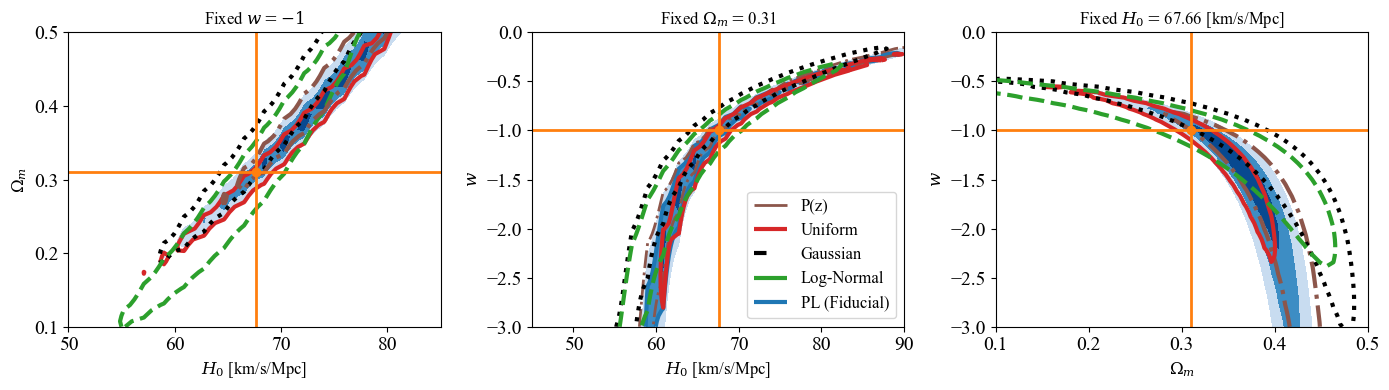

In [48]:
fig = plt.figure(figsize=(14, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

blues = plt.get_cmap("Blues", 10)

chi_2D_min_pl = np.min(chi_2D_H0Om_pl)
ax1.contourf(H_Om, Om_H0, chi_2D_H0Om_pl, levels=[chi_2D_min_pl, chi_2D_min_pl+2.3, chi_2D_min_pl+6.17, chi_2D_min_pl+11.8],\
            cmap='Blues_r')

chi_2D_min_uni = np.min(chi_2D_H0Om_uni)
ax1.contour(H_Om, Om_H0, chi_2D_H0Om_uni, levels=[chi_2D_min_uni+6.17],\
            linestyles='-', colors='tab:red', linewidths=3)
chi_2D_min_ga = np.min(chi_2D_H0Om_ga)
ax1.contour(H_Om, Om_H0, chi_2D_H0Om_ga, levels=[chi_2D_min_ga+6.17],\
            linestyles=':', colors='black', linewidths=3)
chi_2D_min_ln = np.min(chi_2D_H0Om_ln)
ax1.contour(H_Om, Om_H0, chi_2D_H0Om_ln, levels=[chi_2D_min_ln+6.17],\
            linestyles='--', colors='tab:green', linewidths=3)
chi_2D_min = np.min(chi_2D_H0Om)
ax1.contour(H_Om, Om_H0, chi_2D_H0Om, levels=[chi_2D_min+6.17],\
            linestyles='-.', colors='tab:brown', linewidths=3)

ax1.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', zorder=10)
ax1.axhline(y=OMEGA_MATTER, c='tab:orange', lw=2)
ax1.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax1.set_ylabel(r'$\Omega_m$', fontsize=12)
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax1.set_xlim(50, 85)
ax1.set_title(r'Fixed $w=-1$', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=14)


#########################################################
chi_2D_min_pl = np.min(chi_2D_H0w_pl)
ax2.contourf(H_w, w_H, chi_2D_H0w_pl.T, levels=[chi_2D_min_pl, chi_2D_min_pl+2.3, chi_2D_min_pl+6.17, chi_2D_min_pl+11.8], cmap='Blues_r')
CS_pl = ax2.contour(H_w, w_H, chi_2D_H0w_pl.T, levels=[chi_2D_min_pl+6.17],\
            linestyles='-', colors='tab:blue', linewidths=3)
pl_labels, _ = CS_pl.legend_elements()

# chi_2D_min = np.min(chi_2D_H0w)
# ax2.contourf(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
# CS_fid = ax2.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min+2.3],\
#             colors='tab:blue', linestyles='-', linewidths=2)
# fid_labels, _ = CS_fid.legend_elements()

chi_2D_min = np.min(chi_2D_H0w)
# ax2.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
CS_fid = ax2.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min+6.17],\
            colors='tab:brown', linestyles='-.', linewidths=2)
fid_labels, _ = CS_fid.legend_elements()

chi_2D_min_uni = np.min(chi_2D_H0w_uni)
CS_uni = ax2.contour(H_w, w_H, chi_2D_H0w_uni.T, levels=[chi_2D_min_uni+6.17],\
            linestyles='-', colors='tab:red', linewidths=3)
uni_labels, _ = CS_uni.legend_elements()

chi_2D_min_ga = np.min(chi_2D_H0w_ga)
CS_ga = ax2.contour(H_w, w_H, chi_2D_H0w_ga.T, levels=[chi_2D_min_ga+6.17],\
            linestyles=':', colors='black', linewidths=3)
ga_labels, _ = CS_ga.legend_elements()

chi_2D_min_ln = np.min(chi_2D_H0w_ln)
CS_ln = ax2.contour(H_w, w_H, chi_2D_H0w_ln.T, levels=[chi_2D_min_ln+6.17],\
            linestyles='--', colors='tab:green', linewidths=3)
ln_labels, _ = CS_ln.legend_elements()


ax2.scatter(HUBBLE, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax2.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax2.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax2.set_ylabel(r'$w$', fontsize=12)
ax2.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax2.set_xlim(45, 90)
ax2.set_title(r'Fixed $\Omega_m=$'+f'{round(OMEGA_MATTER, 2)}', fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.legend([fid_labels[0]]+[uni_labels[0]]+[ga_labels[0]]+[ln_labels[0]]+[pl_labels[0]],\
           ["P(z)", "Uniform", "Gaussian", "Log-Normal", "PL (Fiducial)"], loc='lower right',\
          fontsize=12)


#########################################################
chi_2D_min_pl = np.min(chi_2D_Omw_pl)
ax3.contourf(Om_w, w_Om, chi_2D_Omw_pl.T, levels=[chi_2D_min_pl, chi_2D_min_pl+2.3, chi_2D_min_pl+6.17, chi_2D_min_pl+11.8],\
            cmap='Blues_r')

chi_2D_min = np.min(chi_2D_Omw)
ax3.contour(Om_w, w_Om, chi_2D_Omw.T, levels=[chi_2D_min+6.17],\
            linestyles='-.', colors='tab:brown', linewidths=3)

chi_2D_min_uni = np.min(chi_2D_Omw_uni)
ax3.contour(Om_w, w_Om, chi_2D_Omw_uni.T, levels=[chi_2D_min_uni+6.17],\
            linestyles='-', colors='tab:red', linewidths=3)
chi_2D_min_ga = np.min(chi_2D_Omw_ga)
ax3.contour(Om_w, w_Om, chi_2D_Omw_ga.T, levels=[chi_2D_min_ga+6.17],\
            linestyles=':', colors='black', linewidths=3)
chi_2D_min_ln = np.min(chi_2D_Omw_ln)
ax3.contour(Om_w, w_Om, chi_2D_Omw_ln.T, levels=[chi_2D_min_ln+6.17],\
            linestyles='--', colors='tab:green', linewidths=3)
# chi_2D_min_pl = np.min(chi_2D_Omw_pl)
# ax3.contour(Om_w, w_Om, chi_2D_Omw_pl.T, levels=[chi_2D_min_pl+6.17],\
#             linestyles='-.', colors='tab:brown', linewidths=3)


ax3.scatter(OMEGA_MATTER, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax3.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax3.axvline(x=OMEGA_MATTER, c='tab:orange', lw=2)
ax3.set_xlabel(r'$\Omega_m$', fontsize=12)
ax3.set_ylabel(r'$w$', fontsize=12)
ax3.set_title(r'Fixed $H_0=$'+f'{HUBBLE} [km/s/Mpc]', fontsize=12)
ax3.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()

if True:
    plt.savefig(save_location+"idealised_3D_inference_multiple_rates.pdf", bbox_inches='tight', dpi=400)

plt.show()

In [49]:
z_range = np.linspace(0.2, 3.0, 500)
DM_values_fid = np.zeros_like(z_range)
DM_values_fit_high = np.zeros_like(z_range)
DM_values_fit_low = np.zeros_like(z_range)

for idx, z_val in enumerate(z_range): 
    DM_values_fid[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_values_fit_high[idx] = dispersion_measure(z_val, 72, 0.4, w=W_LAMBDA)
    DM_values_fit_low[idx] = dispersion_measure(z_val, 61, 0.2, w=W_LAMBDA)

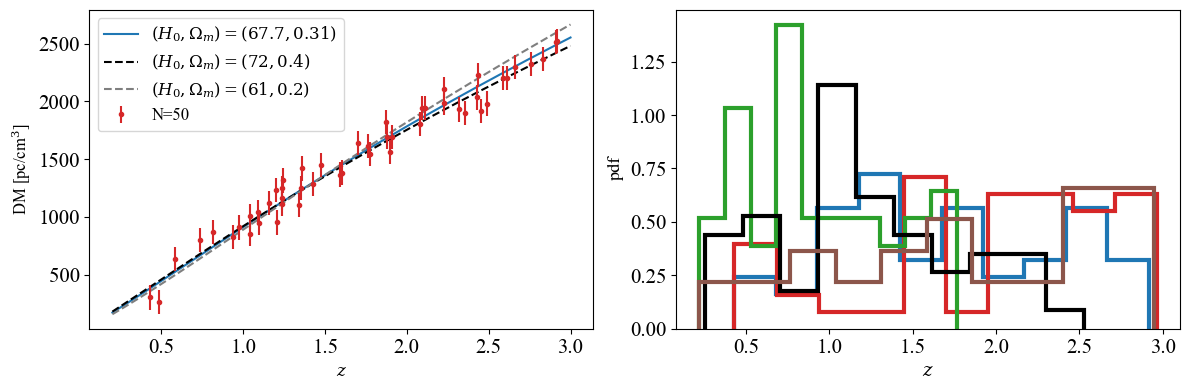

In [50]:
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_range, DM_values_fid, c='tab:blue', label=r'$(H_0, \Omega_m) = (67.7, 0.31)$')
ax1.plot(z_range, DM_values_fit_high, c='black', ls='--', label=r'$(H_0, \Omega_m) = (72, 0.4)$')
ax1.plot(z_range, DM_values_fit_low, c='tab:grey', ls='--', label=r'$(H_0, \Omega_m) = (61, 0.2)$')
ax1.errorbar(z_obs, DM_values_obs, yerr=SIGMA_DM, marker='o', ls='', ms=3, c='tab:red', label=f'N={len(z_obs)}')
ax1.set_ylabel(r'DM [pc/cm$^3$]', fontsize=12)
ax1.set_xlabel(r'$z$', fontsize=12)
ax1.legend(loc='upper left', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=15)

ax2.hist(z_obs, density=True, histtype='step', color='tab:blue', linewidth=3)
ax2.hist(z_obs_uni, density=True, histtype='step', color='tab:red', linewidth=3)
ax2.hist(z_obs_ln, density=True, histtype='step', color='tab:green', linewidth=3)
ax2.hist(z_obs_ga, density=True, histtype='step', color='black', linewidth=3)
ax2.hist(z_obs_pl, density=True, histtype='step', color='tab:brown', linewidth=3)
ax2.set_xlabel(r'$z$', fontsize=13)
ax2.set_ylabel('pdf', fontsize=13)
ax2.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

In [51]:
redshift_array = np.linspace(0.05, 3.0, 500)
Pz_array = rng.choice(redshift_array, size=5000, replace=True,\
                            p=normalise(redshift_distribution(redshift_array, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)))
Pz_gaussian = rng.choice(redshift_array, size=5000, replace=True,\
                            p=normalise(redshift_distribution(redshift_array, method='gaussian')))
Pz_LogNormal = rng.choice(redshift_array, size=5000, replace=True,\
                            p=normalise(redshift_distribution(redshift_array, method='lognormal')))
Pz_power = rng.choice(redshift_array, size=5000, replace=True,\
                            p=normalise(redshift_distribution(redshift_array, method='powerlaw')))

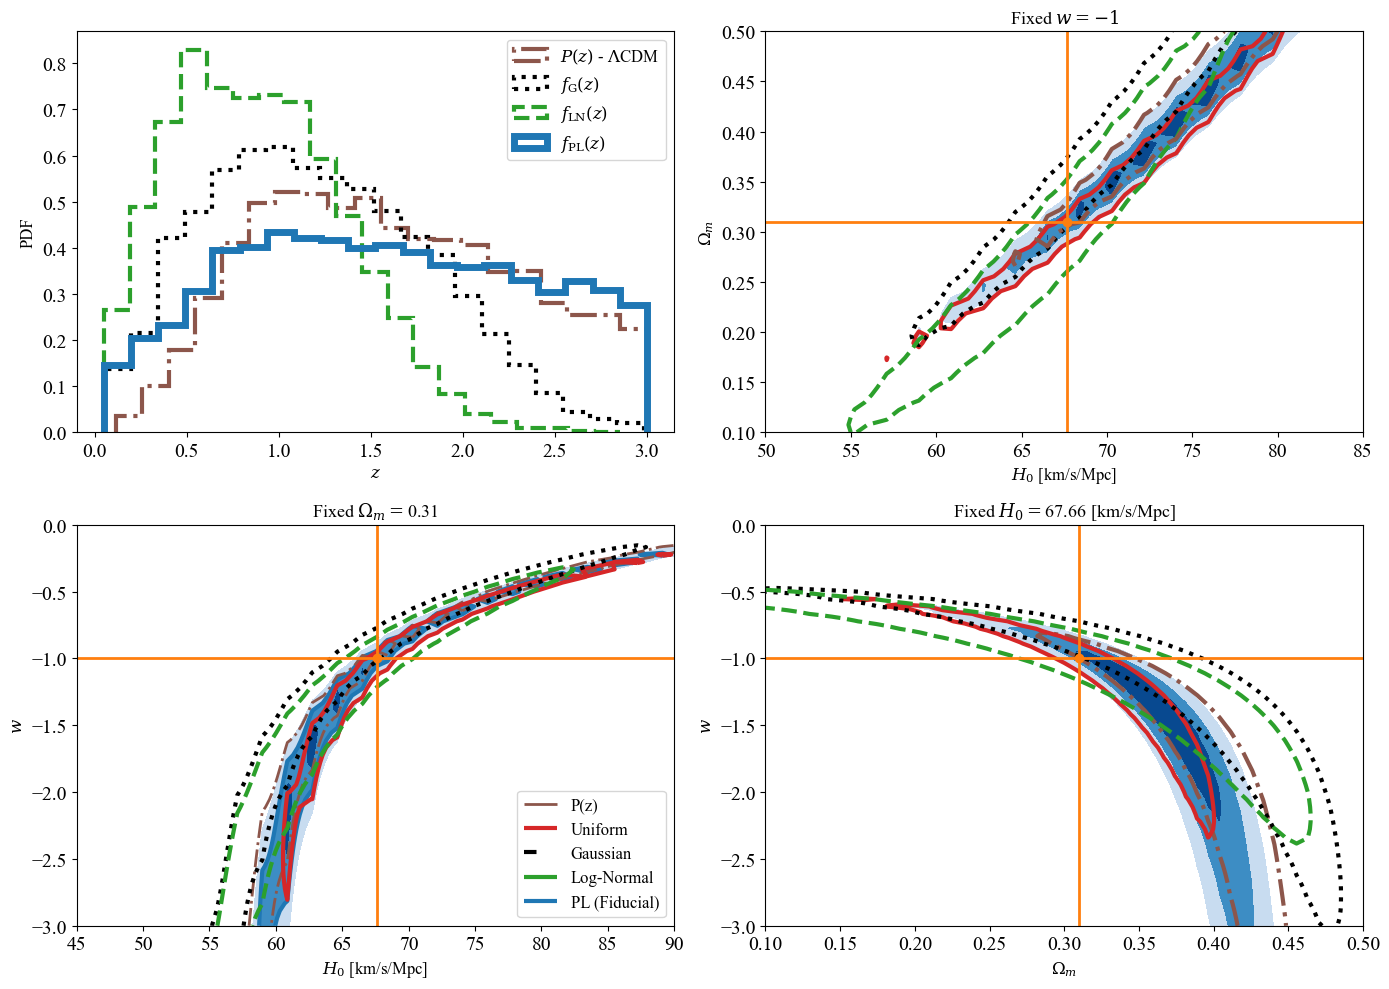

In [52]:
fig = plt.figure(figsize=(14, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

NBins = 20

ax1.hist(Pz_array, bins=NBins, density=True, histtype='step', label=r'$P(z)$ - $\Lambda$CDM',\
         color='tab:brown', linestyle='-.', linewidth=3)
ax1.hist(Pz_gaussian, bins=NBins, density=True, histtype='step', label=r'$f_{\rm G}(z)$',\
         color='black', linestyle=':', linewidth=3)
ax1.hist(Pz_LogNormal, bins=NBins, density=True, histtype='step', label=r'$f_{\rm LN}(z)$',\
         color='tab:green', linestyle='--', linewidth=3)
ax1.hist(Pz_power, bins=NBins, density=True, histtype='step', label=r'$f_{\rm PL}(z)$',\
         color='tab:blue', linestyle='-', linewidth=5)

ax1.set_xlabel(r'$z$', fontsize=12)
ax1.set_ylabel(r'PDF', fontsize=12)
ax1.legend(fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=14)


#########################################################
blues = plt.get_cmap("Blues", 10)

chi_2D_min_pl = np.min(chi_2D_H0Om_pl)
ax2.contourf(H_Om, Om_H0, chi_2D_H0Om_pl, levels=[chi_2D_min_pl, chi_2D_min_pl+2.3, chi_2D_min_pl+6.17, chi_2D_min_pl+11.8],\
            cmap='Blues_r')

chi_2D_min_uni = np.min(chi_2D_H0Om_uni)
ax2.contour(H_Om, Om_H0, chi_2D_H0Om_uni, levels=[chi_2D_min_uni+6.17],\
            linestyles='-', colors='tab:red', linewidths=3)
chi_2D_min_ga = np.min(chi_2D_H0Om_ga)
ax2.contour(H_Om, Om_H0, chi_2D_H0Om_ga, levels=[chi_2D_min_ga+6.17],\
            linestyles=':', colors='black', linewidths=3)
chi_2D_min_ln = np.min(chi_2D_H0Om_ln)
ax2.contour(H_Om, Om_H0, chi_2D_H0Om_ln, levels=[chi_2D_min_ln+6.17],\
            linestyles='--', colors='tab:green', linewidths=3)
chi_2D_min = np.min(chi_2D_H0Om)
ax2.contour(H_Om, Om_H0, chi_2D_H0Om, levels=[chi_2D_min+6.17],\
            linestyles='-.', colors='tab:brown', linewidths=3)

ax2.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', zorder=10)
ax2.axhline(y=OMEGA_MATTER, c='tab:orange', lw=2)
ax2.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax2.set_ylabel(r'$\Omega_m$', fontsize=12)
ax2.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax2.set_xlim(50, 85)
ax2.set_title(r'Fixed $w=-1$', fontsize=13)
ax2.tick_params(axis='both', which='major', labelsize=14)


#########################################################
chi_2D_min_pl = np.min(chi_2D_H0w_pl)
ax3.contourf(H_w, w_H, chi_2D_H0w_pl.T, levels=[chi_2D_min_pl, chi_2D_min_pl+2.3, chi_2D_min_pl+6.17, chi_2D_min_pl+11.8], cmap='Blues_r')
CS_pl = ax3.contour(H_w, w_H, chi_2D_H0w_pl.T, levels=[chi_2D_min_pl+6.17],\
            linestyles='-', colors='tab:blue', linewidths=3)
pl_labels, _ = CS_pl.legend_elements()

# chi_2D_min = np.min(chi_2D_H0w)
# ax2.contourf(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
# CS_fid = ax2.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min+2.3],\
#             colors='tab:blue', linestyles='-', linewidths=2)
# fid_labels, _ = CS_fid.legend_elements()

chi_2D_min = np.min(chi_2D_H0w)
# ax2.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min, chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues_r')
CS_fid = ax3.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min+6.17],\
            colors='tab:brown', linestyles='-.', linewidths=2)
fid_labels, _ = CS_fid.legend_elements()

chi_2D_min_uni = np.min(chi_2D_H0w_uni)
CS_uni = ax3.contour(H_w, w_H, chi_2D_H0w_uni.T, levels=[chi_2D_min_uni+6.17],\
            linestyles='-', colors='tab:red', linewidths=3)
uni_labels, _ = CS_uni.legend_elements()

chi_2D_min_ga = np.min(chi_2D_H0w_ga)
CS_ga = ax3.contour(H_w, w_H, chi_2D_H0w_ga.T, levels=[chi_2D_min_ga+6.17],\
            linestyles=':', colors='black', linewidths=3)
ga_labels, _ = CS_ga.legend_elements()

chi_2D_min_ln = np.min(chi_2D_H0w_ln)
CS_ln = ax3.contour(H_w, w_H, chi_2D_H0w_ln.T, levels=[chi_2D_min_ln+6.17],\
            linestyles='--', colors='tab:green', linewidths=3)
ln_labels, _ = CS_ln.legend_elements()


ax3.scatter(HUBBLE, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax3.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax3.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax3.set_ylabel(r'$w$', fontsize=12)
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
ax3.set_xlim(45, 90)
ax3.set_title(r'Fixed $\Omega_m=$'+f'{round(OMEGA_MATTER, 2)}', fontsize=13)
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.legend([fid_labels[0]]+[uni_labels[0]]+[ga_labels[0]]+[ln_labels[0]]+[pl_labels[0]],\
           ["P(z)", "Uniform", "Gaussian", "Log-Normal", "PL (Fiducial)"], loc='lower right',\
          fontsize=12)


#########################################################
chi_2D_min_pl = np.min(chi_2D_Omw_pl)
ax4.contourf(Om_w, w_Om, chi_2D_Omw_pl.T, levels=[chi_2D_min_pl, chi_2D_min_pl+2.3, chi_2D_min_pl+6.17, chi_2D_min_pl+11.8],\
            cmap='Blues_r')

chi_2D_min = np.min(chi_2D_Omw)
ax4.contour(Om_w, w_Om, chi_2D_Omw.T, levels=[chi_2D_min+6.17],\
            linestyles='-.', colors='tab:brown', linewidths=3)

chi_2D_min_uni = np.min(chi_2D_Omw_uni)
ax4.contour(Om_w, w_Om, chi_2D_Omw_uni.T, levels=[chi_2D_min_uni+6.17],\
            linestyles='-', colors='tab:red', linewidths=3)
chi_2D_min_ga = np.min(chi_2D_Omw_ga)
ax4.contour(Om_w, w_Om, chi_2D_Omw_ga.T, levels=[chi_2D_min_ga+6.17],\
            linestyles=':', colors='black', linewidths=3)
chi_2D_min_ln = np.min(chi_2D_Omw_ln)
ax4.contour(Om_w, w_Om, chi_2D_Omw_ln.T, levels=[chi_2D_min_ln+6.17],\
            linestyles='--', colors='tab:green', linewidths=3)
# chi_2D_min_pl = np.min(chi_2D_Omw_pl)
# ax3.contour(Om_w, w_Om, chi_2D_Omw_pl.T, levels=[chi_2D_min_pl+6.17],\
#             linestyles='-.', colors='tab:brown', linewidths=3)


ax4.scatter(OMEGA_MATTER, W_LAMBDA, marker='o', c='tab:orange', zorder=10)
ax4.axhline(y=W_LAMBDA, c='tab:orange', lw=2)
ax4.axvline(x=OMEGA_MATTER, c='tab:orange', lw=2)
ax4.set_xlabel(r'$\Omega_m$', fontsize=12)
ax4.set_ylabel(r'$w$', fontsize=12)
ax4.set_title(r'Fixed $H_0=$'+f'{HUBBLE} [km/s/Mpc]', fontsize=13)
ax4.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()

if True:
    plt.savefig(save_location+"idealised_3D_inference_multiple_rates.pdf", bbox_inches='tight', dpi=400)

plt.show()

-----------------------------------

# Distances with errors <a name="Uncertain_distance_info"></a>

Now take into account that distances can have errors. To calculate the cosmological parameters, we'll follow a Bayesian approach:

$$
P(\mathbf{H_0}|d_L^{\rm obs}, {\rm DM}^{\rm obs}) \sim \pi(\mathbf{H_0}) \cdot P(d_L^{\rm obs}, {\rm DM}^{\rm obs}|\mathbf{H_0}) = \\
\int dz \ P\left(d_L^{\rm obs}|d_L(z,\mathbf{H_0})\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) \cdot \pi(z)
$$
where with $\mathbf{H_0}$ we denote the _vector_ of cosmological parameters ($H_0, \Omega_m, w$) and $\pi(z)$ is the prior on the redshift distribution of sources and $\pi(\mathbf{H_0})$ the priors on the cosmological parameters. 

For the ${\rm DM}$ part, we can introduce the contributions of different sources as systematic errors and marginalise over them. In reality, we can estimate ${\rm DM}_{\rm IGM}$ as:

$$
{\rm DM}_{\rm IGM} = {\rm DM}^{\rm obs} - {\rm DM}^{\rm MW} - {\rm DM}^{\rm HG}/(1+z), 
$$

where ${\rm DM}^{\rm MW} = {\rm DM}^{\rm MW}_{\rm halo} + {\rm DM}^{\rm MW}_{\rm ISM}$. So we can write $P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right)$ as:

$$
P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) = \int d{\rm DM}^{\rm MW} d{\rm DM}^{\rm HG} \pi({\rm DM}^{\rm MW}) \pi({\rm DM}^{\rm HG}) P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}), {\rm DM}^{\rm MW}, {\rm DM}^{\rm HG} \right).
$$

Return to TOC [here](#toc).

### 1. **Simplified version**

Before analysing the problem in its full complexity, let's investigate a simplified version, where:

1. The prior on redshifts is flat (so we can ignore $\pi(z)$).
2. We are able to measure (as in the previous sections) directly ${\rm DM}_{\rm IGM}$, so we do not need to worry about the other contributions.
3. We keep the errors ($\sigma_{d_L}, \sigma_{{\rm DM}}$) fixed.

We then simply have:
$$
P(\mathbf{H_0}|d_L^{\rm obs}, {\rm DM}^{\rm obs}) \sim \int dz \ P\left(d_L^{\rm obs}|d_L(z, \mathbf{H_0})\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0})\right)\ ({\rm S*}).
$$

**NB**: We ignore selection effects, having done a redshift cut ($z<2$), where all events would be observable by future detectors.

### Simplified version: **1 event**

The steps we follow to create mock data are the following:

1. Choose (randomly) a redshift.
2. For the fiducial cosmology, calculate $d_L^{\rm obs}$ and ${\rm DM}^{\rm obs}$.
3. Add some scatter around the true values, by generating updated observed values through $d^{\rm obs}_{\rm L, new} = \mathcal{N}(d_L^{\rm obs}, \sigma_{d_L})$ and ${\rm DM}^{\rm obs}_{\rm new} = \mathcal{N}({\rm DM}^{\rm obs}, \sigma_{\rm DM})$.
4. Draw some samples around the new values, to recreate some realistic posteriors.

We then use these, to fit for the cosmological parameters (according to $({\rm S*})$).

In [9]:
## Random choice of redshift
z_centre = 0.7

# Theoretical dL, fiducial cosmo
cosmo_fid = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER)
dL_centre = cosmo_fid.luminosity_distance(z_centre).value

# Theoretical DM, fiducial cosmo
DM_centre = dispersion_measure(z_centre, H0=HUBBLE, Om=OMEGA_MATTER)

We create the distance posteriors, by moving around the central values and assuming observational errors.

In [9]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centre
dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

## Choice of observed DM
sigma_DM = 105
DM_obs_centre = np.random.normal(DM_centre, sigma_DM)

In [10]:
## Creating the posteriors around the observed values

dL_gaussian = np.random.normal(dL_obs_centre, sigma_dL, 1000)

DM_gaussian = np.random.normal(DM_obs_centre, sigma_DM, 1000)

To avoid unphysical (negative) values for distances, we are going to set these to zero:

In [11]:
## Here we are imposing a hard cut
dL_gaussian[dL_gaussian<0]=0
DM_gaussian[DM_gaussian<0]=0

In [12]:
## Fitting KDEs around the observed events
GW_dL_kde = gaussian_kde(dL_gaussian)
FRB_DM_kde = gaussian_kde(DM_gaussian)

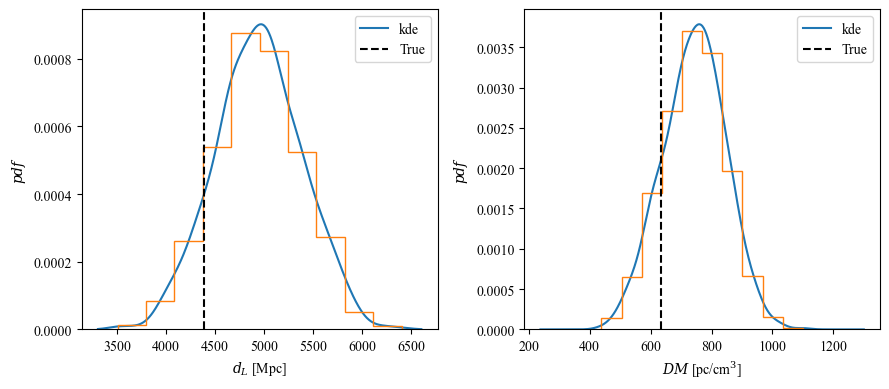

In [13]:
dl_array=np.linspace(np.min(dL_gaussian)-200, np.max(dL_gaussian)+200, 500)
DM_array=np.linspace(np.min(DM_gaussian)-200, np.max(DM_gaussian)+200, 500)

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(dl_array, GW_dL_kde(dl_array), label='kde')
ax1.hist(dL_gaussian, density=True, histtype='step')
ax1.axvline(x=dL_centre, ls='--', c='black', label='True')
ax1.set_xlabel(r'$d_L$ [Mpc]')
ax1.set_ylabel(r'$pdf$')
ax1.legend()


ax2.plot(DM_array, FRB_DM_kde(DM_array), label='kde')
ax2.hist(DM_gaussian, density=True, histtype='step')
ax2.axvline(x=DM_centre, ls='--', c='black', label='True')
ax2.set_xlabel(r'$DM$ [pc/cm$^3$]')
ax2.set_ylabel(r'$pdf$')
ax2.legend()

plt.tight_layout()
plt.show()

We now create a redshift range capable of covering the full range of $d_L$ and ${\rm DM}$. In practice, this is our prior on redshifts (which can be quite agnostic).

In [14]:
## Redshift range
z_array=np.linspace(0.1, 5.5, 500)

## Luminosity distance and DM range for fiducial cosmology (for visualisation purposes)
## i.e. we are transforming our redshift range to distances and DMs
lum_distance = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER).luminosity_distance(z_array).value

DM_distance = []
for z_val in z_array:
    DM_distance.append(dispersion_measure(z_val, H0=HUBBLE, Om=OMEGA_MATTER))
    
DM_distance = np.array(DM_distance)

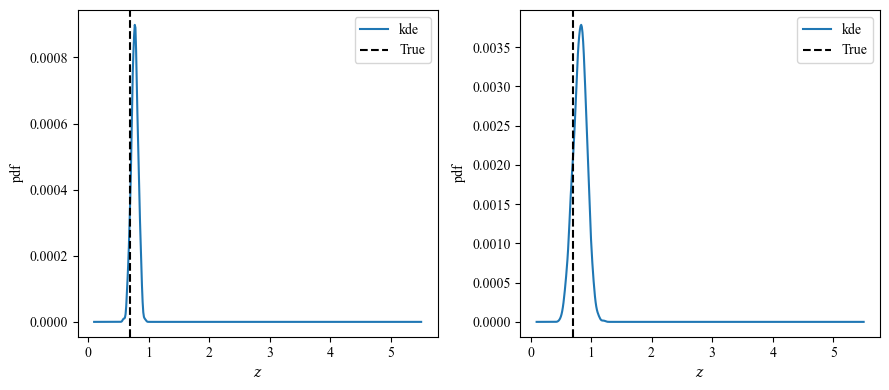

In [15]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_array, GW_dL_kde(lum_distance), label='kde')
ax1.axvline(x=z_centre, ls='--', c='black', label='True')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'pdf')
ax1.legend()


ax2.plot(z_array, FRB_DM_kde(DM_distance), label='kde')
ax2.axvline(x=z_centre, ls='--', c='black', label='True')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'pdf')
ax2.legend()

plt.tight_layout()
plt.show()

**$H_0$ inference, assuming a fixed $\Omega_m$**. 

For a given $H_0$, we produce a distance and ${\rm DM}$ range (keeping $\Omega_m$ fixed). We weigh these by comparing to our observed pdfs for $d_L$ and ${\rm DM}$. Since these two observations were made independently, we multiply their LHDs, and marginalise (integrate) over redshift, i.e. we're calculating the formula $({\rm S*})$ above, to get $P(H_0)$. Finally, we normalize the $P(H_0)$ to get the cosmological constraints.

$$ P(H_0)=\int P(D_L|H_0,z)P(DM|H_0,z) \pi(z) dz $$

In [16]:
### These are our priors
H0_array = np.linspace(10, 140, 100)
Omega_m_array = np.linspace(0.1, 0.5, 60)
w_array = np.linspace(-3.0, 0.0, 65)

## For 2D case
H_Om, Om_H0 = np.meshgrid(H0_array, Omega_m_array)
H_w, w_H = np.meshgrid(H0_array, w_array)
Om_w, w_Om = np.meshgrid(Omega_m_array, w_array)

## For 3D case
H_3D, Om_3D, w_3D = np.meshgrid(H0_array, Omega_m_array, w_array)

## We vectorise dispersion measure (this is just a normal loop under the hood)
## Note that the arguments are (z, H0, Om, w) in the original function
vecDM = np.vectorize(dispersion_measure)
vecDL = np.vectorize(luminosity_distance)

$ H_0$ constraints:

In [19]:
posterior_normed = np.zeros_like(H0_array)

### For each H0 value, we calculate the integral
for i, H0 in enumerate(H0_array):
    
    ## The luminosity distance for given H0, for all z
    lum_distance = FlatLambdaCDM(H0=H0, Om0=OMEGA_MATTER).luminosity_distance(z_array).value
    
    ## The DM for given H0, for all z
    DM_distance=vecDM(z_array, H0=H0, Om=OMEGA_MATTER) 
   
    ## Integrate out the redshift dependence
    posterior_normed[i] = np.trapezoid(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)

## Normalise posterior
posterior_normed/=np.trapezoid(posterior_normed, H0_array)

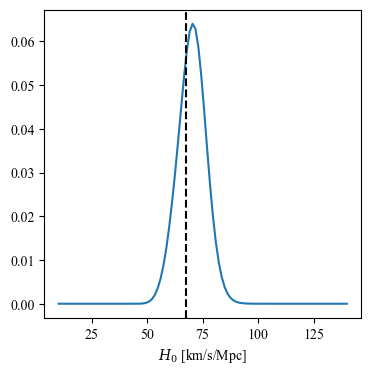

In [20]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)

ax1.plot(H0_array, posterior_normed, label='kde')
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')

plt.show()

**$H_0$ and $\Omega_m$ constraints**

We now perform the same exercise, but also vary $\Omega_m$.

**NB**: This takes quite a lot of time for a high-resolution grid.

In [21]:
z_array=np.linspace(0.1, 1.5, 100) ## We make this lower-res, because it creates a bottleneck

posterior_2D = np.zeros_like(H_Om)

### For each H0 value, we calculate the integral
for i, H0 in enumerate(tqdm(H0_array)):
    for j, Omega_m in enumerate(Omega_m_array):
        lum_distance = FlatLambdaCDM(H0=H0, Om0=Omega_m).luminosity_distance(z_array).value
        DM_distance = vecDM(z_array, H0=H0, Om=Omega_m)

        ## Integrate out the redshift dependence
        posterior_2D[j,i] = np.trapezoid(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)

### We normalise the posterior
total_p = np.sum(posterior_2D)
posterior_2D_normed = posterior_2D/total_p

C:\Users\klera\AppData\Local\Temp\ipykernel_18048\1579612517.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posterior_2D[j,i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)


Finding the percentages in the contour plots (as above):

In [23]:
## Calculate the contour levels (automate the procedure with a finction)
t_contours_post2D = posterior_contour_2D(posterior_2D_normed)

In [24]:
## These are already normalised (no need to normalise again, if we don't want to)

P_Om = normalise(np.sum(posterior_2D_normed, axis=1))
P_H0 = normalise(np.sum(posterior_2D_normed, axis=0))

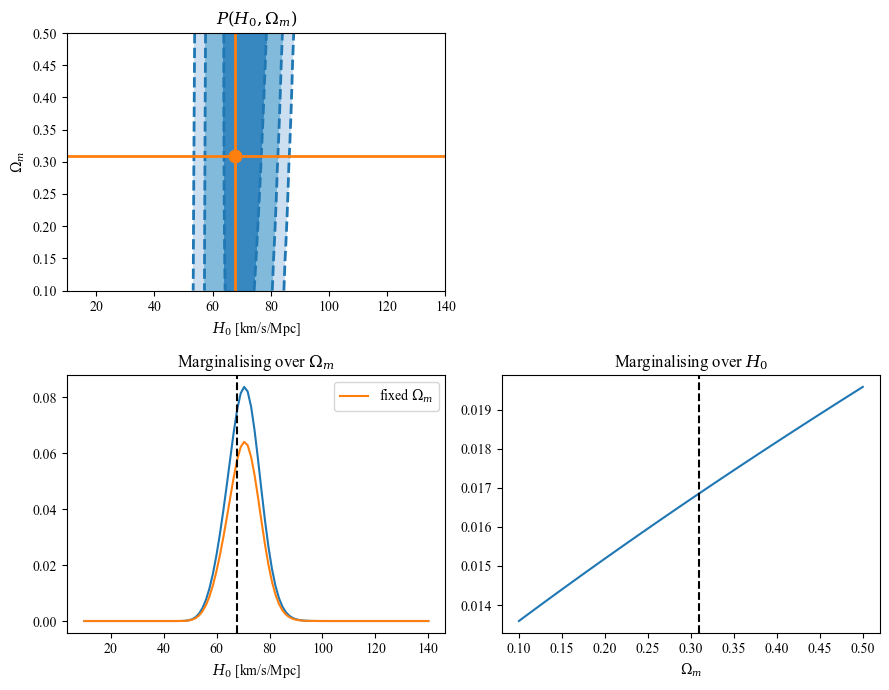

In [26]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = plt.get_cmap("Blues", 10)

ax1.contourf(H_Om, Om_H0, posterior_2D_normed, levels=t_contours_post2D, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, posterior_2D_normed, levels=t_contours_post2D, colors="tab:blue", linewidths=2, linestyles='--')
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='o', c='tab:orange', s=80, zorder=10)
ax1.axhline(y=OMEGA_MATTER, c='tab:orange', lw=2)
ax1.axvline(x=HUBBLE, c='tab:orange', lw=2)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_title(r'$P(H_0, \Omega_m)$')

ax3.plot(H0_array, P_H0)
ax3.plot(H0_array, posterior_normed, label=r'fixed $\Omega_m$')
ax3.axvline(x=HUBBLE, ls='--', c='black')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax3.set_title(r'Marginalising over $\Omega_m$')
ax3.legend()

ax4.plot(Omega_m_array, P_Om)
ax4.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_title(r'Marginalising over $H_0$')

plt.tight_layout()
plt.show()

### **Multiple events**

Extend the analysis above to multiple events.


$$ P(H_0)=  \int \Big[ \Pi_i P(D_L^{\rm obs}|D_L(H_0,z))P(DM^{\rm obs}|DM(H_0,z)) \Big] \pi(z) dz $$

In [31]:
## Redshift range of analysis
z_range = np.linspace(0.5, 1.7, 500)

## Draw N_events sources for analysis
N_events = 15
z_obs = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=N_events, method='uniform')

## Luminosity distance
cosmo_fid = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER)
dL_centres = cosmo_fid.luminosity_distance(z_obs).value

DM_centres = np.zeros_like(dL_centres)

for idx, z_val in enumerate(z_obs): 
    DM_centres[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)

In [23]:
DATA_PATH = '../FRB_cosmo/interpolation/095_C0mean.npz'
Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = FRBs_load_and_create_interpolators(DATA_PATH)

In [50]:
## Modelling the DM pdf -- Standard cosmology
DM_obs_centre_fid_cosmo = np.zeros_like(z_obs)
s_DM_obs_fid_cosmo = np.zeros_like(z_obs)
int_N_DM = 2000

DM_pdfs = np.zeros((N_events, int_N_DM))

for idx, z_val in enumerate(tqdm(z_obs)):
    DM_obs_centre_fid_cosmo[idx], s_DM_obs_fid_cosmo[idx], DM_pdfs[idx, :] = \
        DM_diff_sampling(z=z_val, 
                        S=S_FRB, HOF=HOF,
                        sigma_error_inter=sigma_error_inter,
                        C0_sigma_inter=C0_sigma_inter,
                        A_sigma_inter=A_sigma_inter,
                        H0=HUBBLE, f_diff=f_IGM, f_diff_alpha=f_ALPHA,
                        Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
                        mode='standard',
                        Error_factor = 0.05
                        )

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 14.25it/s]


In [25]:
sim_error_interpolations = np.load(f'../Realistic_sources/quantile_linear_interpolations.npz')

LVK_error = sim_error_interpolations['LVK_interpolation']
CE_error = sim_error_interpolations['CE_interpolation']

**MK-TO DO**: Move to python scripts

In [26]:
def GWs_error(z, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, method='constant'):
    if method=='LVK':
        sigma_ratio = func_lin(z, *LVK_error)/100
        dL=luminosity_distance(z, H0, Om, w)
        return sigma_ratio*dL
    elif method=='CE':
        sigma_ratio = func_lin(z, *CE_error)/100
        dL=luminosity_distance(z, H0, Om, w)
        return sigma_ratio*dL
    elif method=='Wei':
        return sigma_dL(z, H0, Om, w, method=method)
    elif method=='constant':
        return sigma_dL(z, H0, Om, w, method=method)
    else:
        print("Wrong error generation method! Choose from: 'LVK', 'CE', 'Wei', and 'constant'.")

In [42]:
## Calculate errors
sigma_dL_obs = 0.1*GWs_error(z_obs, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, method='constant')

## Scatter observations according to errors
dL_obs_centres = rng.normal(dL_centres, sigma_dL_obs)

In [14]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centres

## Choice of observed DM
sigma_DM = 105

dL_obs_centres = np.zeros_like(zs_centre)
DM_obs_centres = np.zeros_like(zs_centre)

for idx, dL in enumerate(dL_centres):
    dL_obs_centres[idx] = np.random.normal(dL, sigma_dL[idx])
    DM_obs_centres[idx] = np.random.normal(DM_centres[idx], sigma_DM)

NameError: name 'zs_centre' is not defined

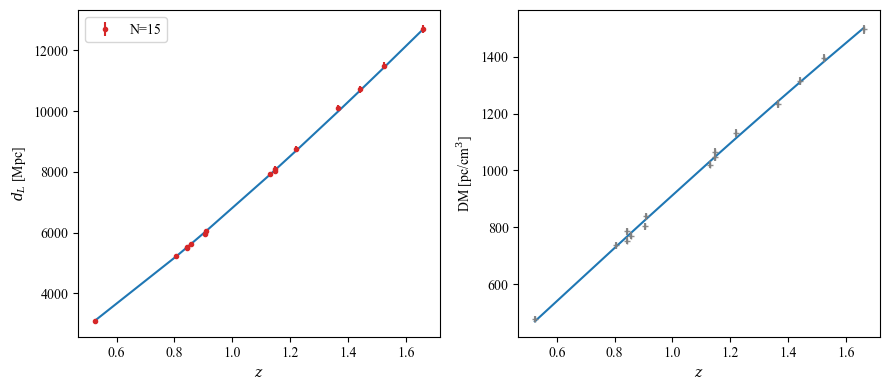

In [51]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.sort(z_obs), np.sort(dL_centres))
ax1.errorbar(z_obs, dL_obs_centres, yerr=sigma_dL_obs, marker='o', ls='', ms=3, c='tab:red', label=f'N={len(z_obs)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(z_obs), np.sort(DM_centres))
ax2.errorbar(z_obs, DM_obs_centre_fid_cosmo, yerr=s_DM_obs_fid_cosmo, marker='+',\
             ls='', ms=5, c='tab:grey', label='Fiducial Cosmo', alpha=0.9)
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

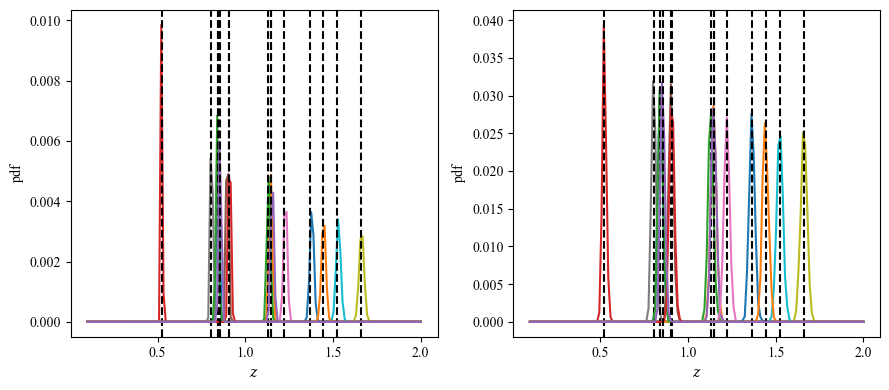

In [54]:
### These are our priors
H0_array = np.linspace(50, 80, 180)
z_array=np.linspace(0.1, 2.0, 150)

posterior_normed = np.zeros_like(H0_array)
posterior_LHD_all = np.ones((len(H0_array), len(z_array)))
likelihoods_normed = np.ones((len(H0_array), len(z_array)))
posterior_normed_all_25 = np.ones_like(H0_array)

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

for idx, dL in enumerate(dL_obs_centres):
    dL_gaussian = np.random.normal(dL, sigma_dL_obs[idx], int_N_DM)

    # dL_min = np.max([0, dL-3*sigma_dL_obs[idx]])
    # dL_array = np.linspace(dL_min, dL+3*sigma_dL_obs[idx], 1000)
    # dL_gaussian = gaussian_pdf(dL_array, dL, sigma_dL_obs[idx])

    DM_pdf = DM_pdfs[idx]
    
    ## Fitting KDEs around the observed events
    GW_dL_kde = gaussian_kde(dL_gaussian)
    FRB_DM_kde = gaussian_kde(DM_pdf)

    lum_distance=FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER).luminosity_distance(z_array).value

    DM_distance = []
    for z_val in z_array:
        DM_distance.append(dispersion_measure(z_val, Om=OMEGA_MATTER, H0=HUBBLE))

    DM_distance = np.array(DM_distance)    

    ax1.plot(z_array, GW_dL_kde(lum_distance))
    ax1.axvline(x=z_obs[idx], ls='--', c='black')
    ax1.set_xlabel(r'$z$')
    ax1.set_ylabel(r'pdf')
    
    ax2.plot(z_array, FRB_DM_kde(DM_distance))
    ax2.axvline(x=z_obs[idx], ls='--', c='black')
    ax2.set_xlabel(r'$z$')
    ax2.set_ylabel(r'pdf')
    
    for i, H0 in enumerate(H0_array):
        lum_distance=FlatLambdaCDM(H0=H0, Om0=OMEGA_MATTER).luminosity_distance(z_array).value
        
        # DM_distance = []
        # for z_val in z_array:
        #     DM_distance.append(dispersion_measure(z_val, Om=OMEGA_MATTER, H0=H0))

        # DM_distance = np.array(DM_distance)
        
        posterior_normed[i] = np.trapezoid(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array) #
        # likelihoods_normed[i, :] = GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance)

        
    # posterior_normed/=np.trapezoid(posterior_normed, H0_array)
    
    posterior_normed_all_25=posterior_normed_all_25*posterior_normed
    posterior_normed_all_25/=np.trapezoid(posterior_normed_all_25, H0_array)
    # posterior_LHD_all += np.log10(likelihoods_normed+1e-15)


plt.tight_layout()
plt.show()    

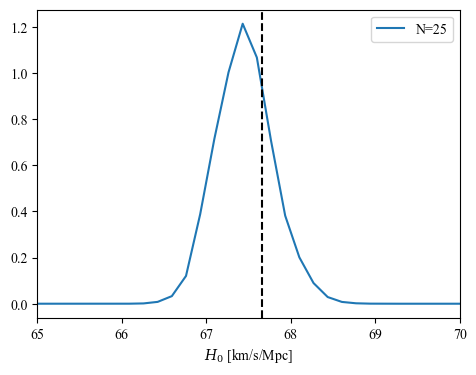

In [56]:
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)

# posterior_LHDs = np.trapezoid(10**posterior_LHD_all*np.exp(-(z_array-1.0)**2/0.2**2), z_array, axis=1) #*np.exp(-(z_array-1.0)**2/0.2**2)
# posterior_LHDs /= np.trapezoid(posterior_LHDs, H0_array)

# H0_inf = np.trapezoid(H0_array*posterior_LHDs, x=H0_array)

# ax1.plot(H0_array, posterior_normed_all, label='N=5')
# ax1.plot(H0_array, posterior_normed_all_15, label='N=15')
ax1.plot(H0_array, posterior_normed_all_25, label='N=25')
# ax1.plot(H0_array, np.exp(-(H0_array-HUBBLE)**2/100))
# ax1.plot(H0_array, posterior_LHDs, ls='--', label='LHD')
ax1.axvline(x=HUBBLE, ls='--', c='black')
# ax1.axvline(x=H0_inf, ls='-', c='tab:red', label=f'H0:{round(H0_inf,2)}')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.legend()
ax1.set_xlim(65, 70)

plt.show()

In [366]:
## Luminosity distance
dL_centres_inf = FlatLambdaCDM(H0=H0_inf, Om0=OMEGA_MATTER).luminosity_distance(z_array).value

## DM measure
DM_centres_inf=vecDM(z_array, Om=OMEGA_MATTER, H0=H0_inf)

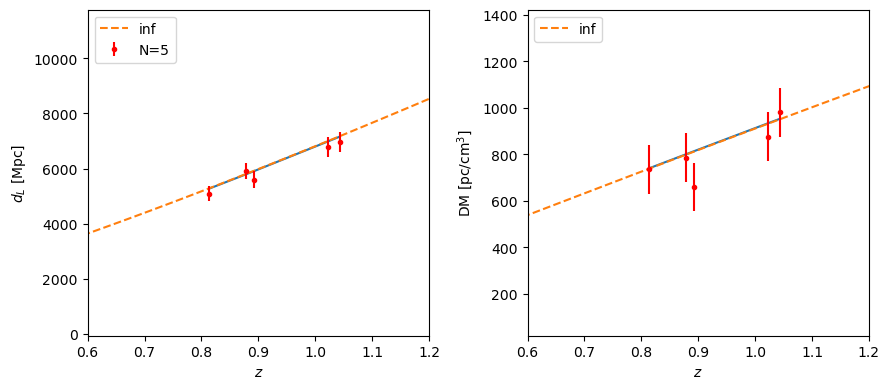

In [367]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.sort(zs_centre), np.sort(dL_centres))
ax1.plot(z_array, dL_centres_inf, ls='--', label='inf')
ax1.errorbar(zs_centre, dL_obs_centres, yerr=sigma_dL, marker='o', ls='', ms=3, c='r', label=f'N={len(zs_centre)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')
ax1.set_xlim(0.6, 1.2)
# ax1.set_ylim(0.0, 1.2e4)

ax2.plot(np.sort(zs_centre), np.sort(DM_centres))
ax2.plot(z_array, DM_centres_inf, ls='--', label='inf')
ax2.errorbar(zs_centre, DM_obs_centres, yerr=sigma_DM, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')
ax2.legend(loc='upper left')
ax2.set_xlim(0.6, 1.2)
# ax2.set_ylim(0.0, 1.6e3)

plt.tight_layout()
plt.show()

**$H_0$ and $\Omega_m$ constraints**

In [150]:
posterior_2D = np.zeros_like(H_Om)
posterior_2D_all = np.ones_like(H_Om)

for idx, dL in enumerate(dL_obs_centres):
    dL_gaussian = np.random.normal(dL, sigma_dL[idx], 1000)
    DM_gaussian = np.random.normal(DM_obs_centres[idx], sigma_DM, 1000)
    
    ## Fitting KDEs around the observed events
    GW_dL_kde = gaussian_kde(dL_gaussian)
    FRB_DM_kde = gaussian_kde(DM_gaussian)
    
    for i, H0 in enumerate(H0_array):
        for j, Om in enumerate(Omega_m_array):
            lum_distance=FlatLambdaCDM(H0=H0, Om0=Om).luminosity_distance(z_array).value
            DM_distance = vecDM(z_array, H0=H0, Om=Om)

            posterior_2D[j,i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)
        
    posterior_2D=normalise(posterior_2D)
    posterior_2D_all=posterior_2D_all*posterior_2D

posterior_2D_all=normalise(posterior_2D_all)

In [151]:
t_contours_post2D = posterior_contour_2D(posterior_2D_all)
P_Om = normalise(np.sum(posterior_2D_all, axis=1))
P_H0 = normalise(np.sum(posterior_2D_all, axis=0))

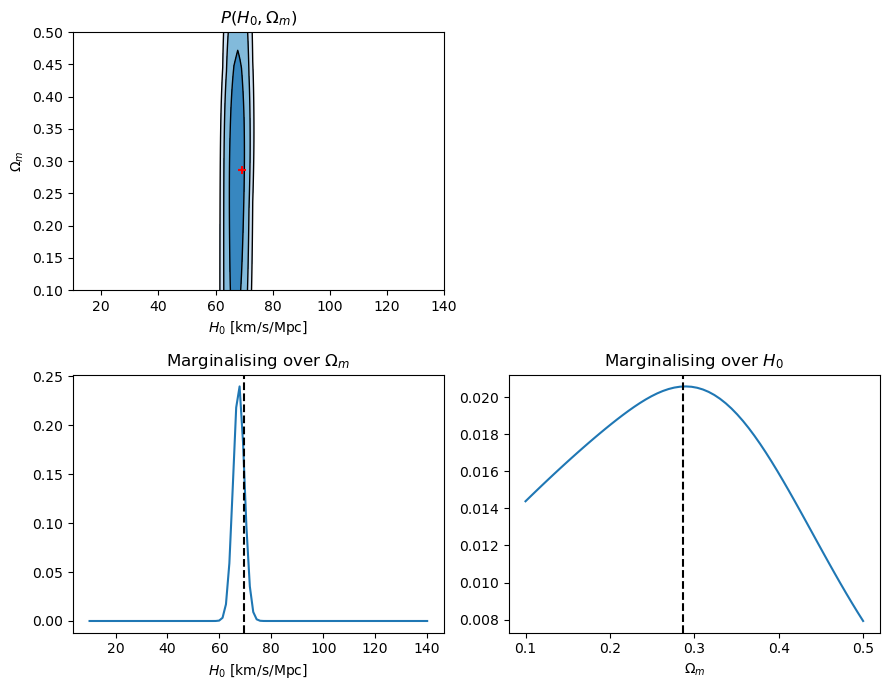

In [154]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = cm.get_cmap("Blues", 10)

ax1.contourf(H_Om, Om_H0, posterior_2D_all, levels=t_contours_post2D, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, posterior_2D_all, levels=t_contours_post2D, colors="black", linewidths=1)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_title(r'$P(H_0, \Omega_m)$')

ax3.plot(H0_array, P_H0)
ax3.axvline(x=HUBBLE, ls='--', c='black')
ax3.set_xlabel(fr'$H_0$ [km/s/Mpc]')
ax3.set_title(r'Marginalising over $\Omega_m$')

ax4.plot(Omega_m_array, P_Om)
ax4.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_title(r'Marginalising over $H_0$')

plt.tight_layout()
plt.show()

-----------------------------------------

-----------------------------------------------------

# Appendix

## A1 - Checking cosmological functions <a name="AP_Cosmo_functions"></a>

Return to TOC [here](#toc).

1. Reproduce Figure 2 of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)], to check our definitions of luminosity distance and dispersion measure.

In [54]:
z_range = np.linspace(0.2, 2.0, 50)

dL_values_astropy = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER).luminosity_distance(z_range).value

dL_values = np.zeros_like(z_range)
DM_values = np.zeros_like(z_range)

for idx, z_val in enumerate(z_range): 
    dL_values[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    DM_values[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)

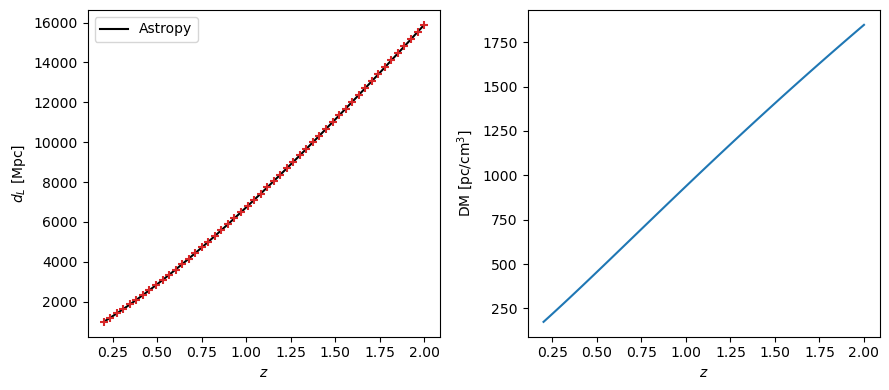

In [55]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_range, dL_values_astropy, ls='-', c='black', label='Astropy')
ax1.scatter(z_range, dL_values, s=35, marker='+', c='tab:red', zorder=10)
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend()

ax2.plot(z_range, DM_values)
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

2. Check that `dLDM_measure` is the same as $dL \cdot {\rm DM}$. Normalise wrt Einstein-deSitter (EdS) Universe, i.e. $\Omega_m = 1$, to compare with FIgure 1 (right), pink line of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [55]:
dLDM_theory = dL_values*DM_values
dLDM_values = np.zeros_like(z_range)
dLDM_values_EdS = np.zeros_like(z_range)


for idx, z_val in enumerate(z_range): 
    dLDM_values[idx] = dLDM_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    dLDM_values_EdS[idx] = dLDM_measure(z_val, HUBBLE, Om=1, w=-1)    

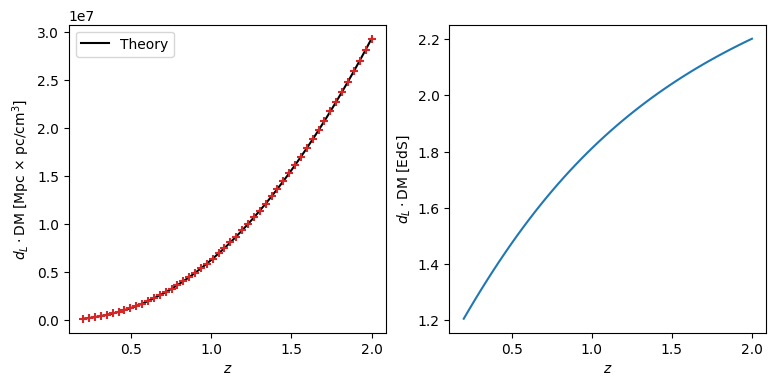

In [56]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)


ax1.plot(z_range, dLDM_theory, ls='-', c='black', label='Theory')
ax1.scatter(z_range, dLDM_values, s=35, marker='+', c='tab:red', zorder=10)
ax1.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [Mpc $\times$ pc/cm$^3$]')
ax1.set_xlabel(r'$z$')
ax1.legend()

ax2.plot(z_range, dLDM_values/dLDM_values_EdS)
ax2.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [EdS]')
ax2.set_xlabel(r'$z$')

plt.show()